In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ========================
# ==== CONFIG ============
# ========================
results_path = "results_by_state_year"

all_data = []

# ========================
# ==== LOAD & MERGE ======
# ========================
for root, _, files in os.walk(results_path):
    for file in files:
        if not file.endswith(".csv"):
            continue

        file_path = os.path.join(root, file)
        df = pd.read_csv(file_path)

        # Exemplo esperado:
        # qualquer_coisa_STATE_YEAR.csv
        parts = file.replace(".csv", "").split("_")
        year = int(parts[-1])
        state = parts[-2].upper()

        df_long = df.melt(
            id_vars=["Modelo"],
            var_name="Produto",
            value_name="MAPE"
        )

        df_long["Year"] = year
        df_long["State"] = state

        all_data.append(df_long)

# ========================
# ==== CLEANUP ===========
# ========================
df_all = pd.concat(all_data, ignore_index=True)

df_all = df_all[df_all["Produto"] != "Unnamed: 0"]

df_all = (
    df_all
    .replace([float("inf"), float("-inf")], pd.NA)
    .dropna(subset=["MAPE"])
)


In [2]:
df_all.head()

,Modelo,Produto,MAPE,Year,State
0,Moirai,Etanolhidratado,10.1331,2020,AC
1,Time-MoE,Etanolhidratado,8.4120,2020,AC
2,TimesFM,Etanolhidratado,15.2567,2020,AC
3,Timer,Etanolhidratado,11.2284,2020,AC
4,Chronos,Etanolhidratado,23.8171,2020,AC


Calculando matrizes bayesianas...
Plotando matrizes...



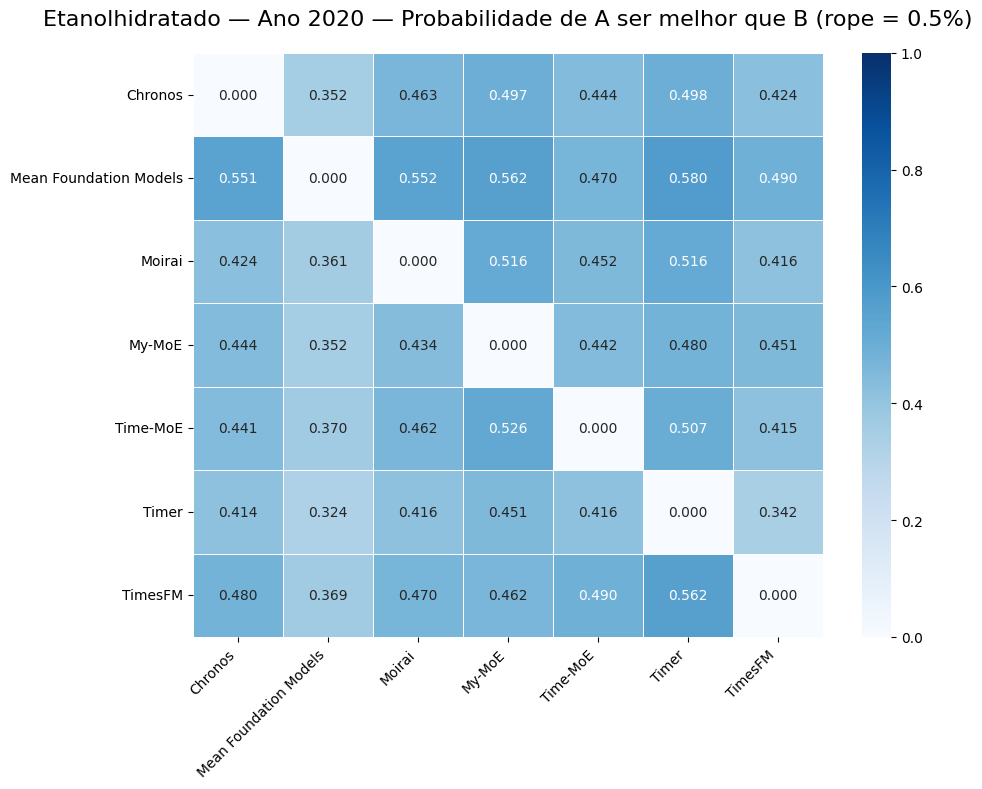

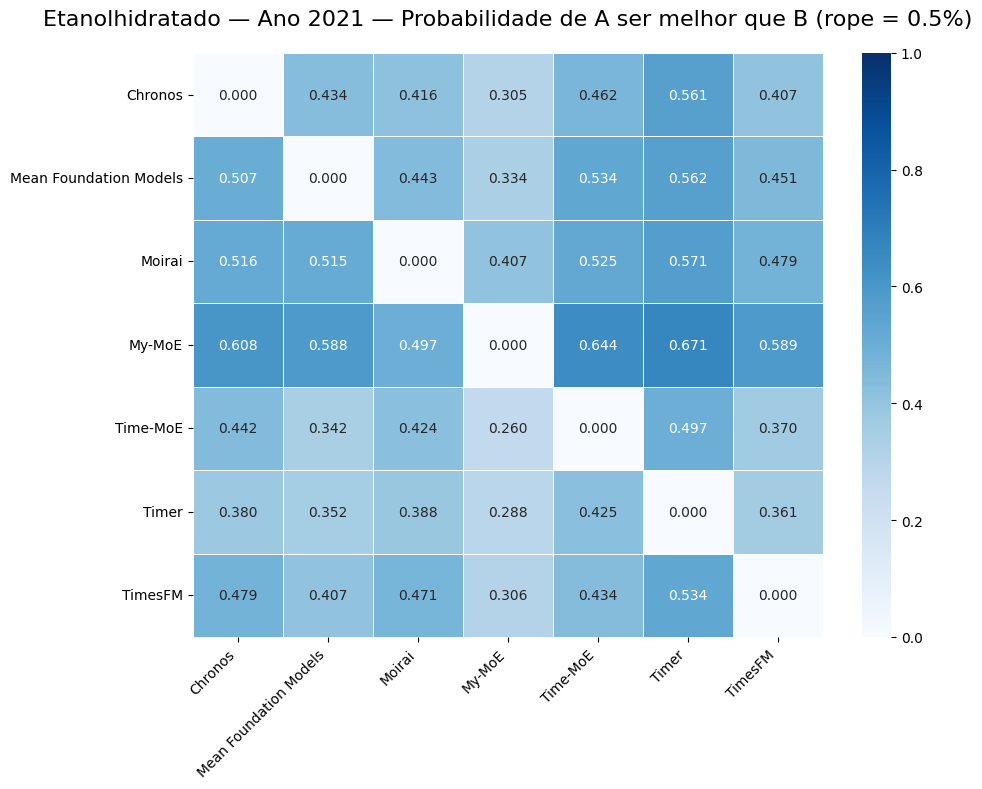

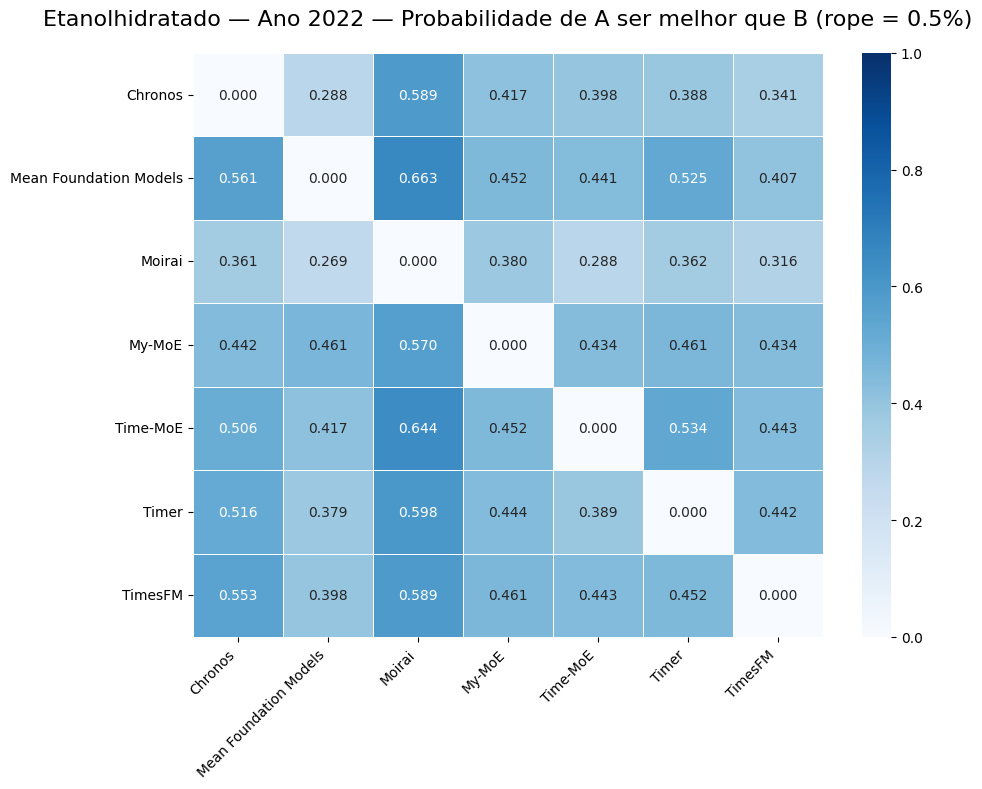

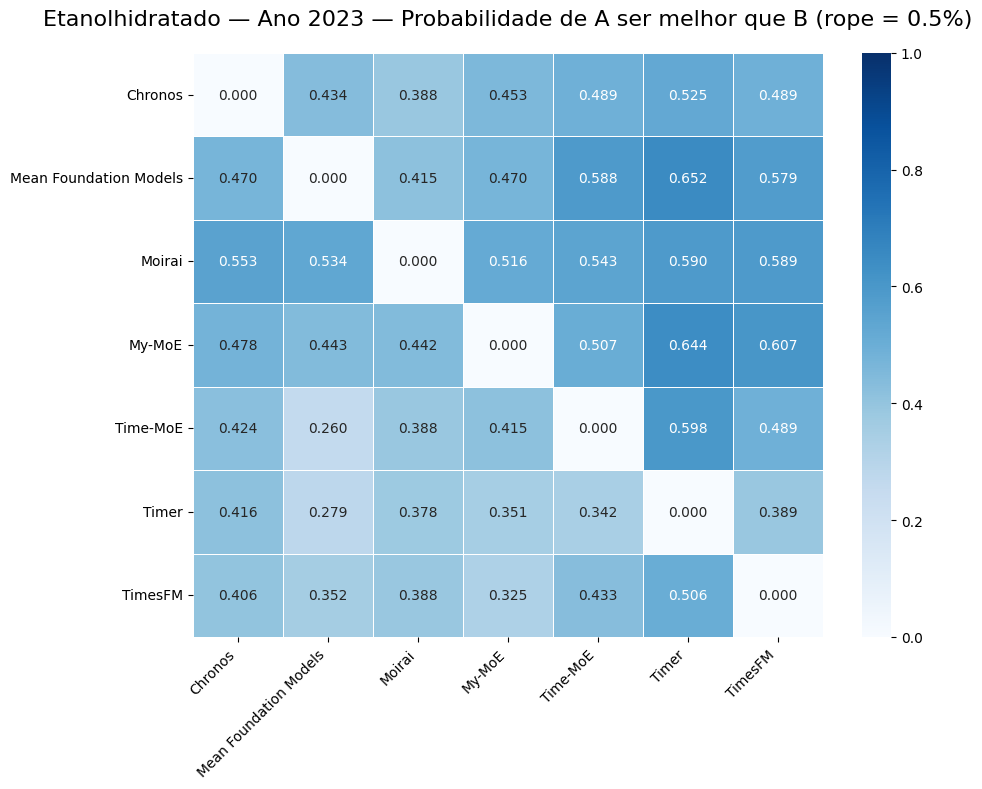

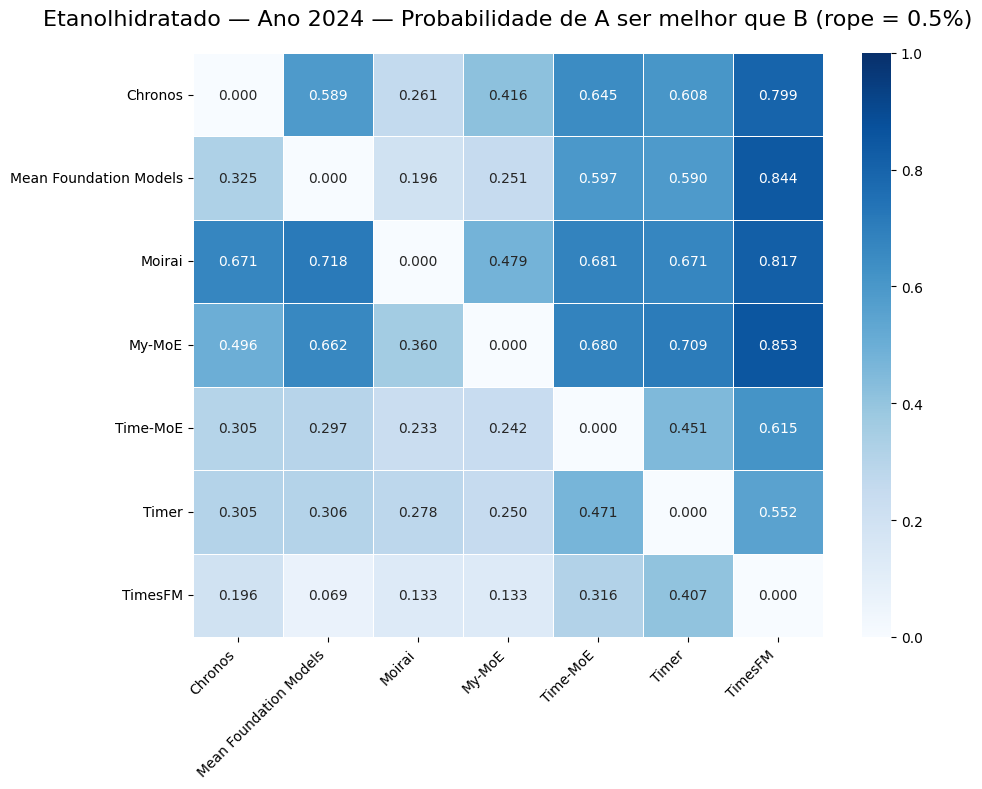

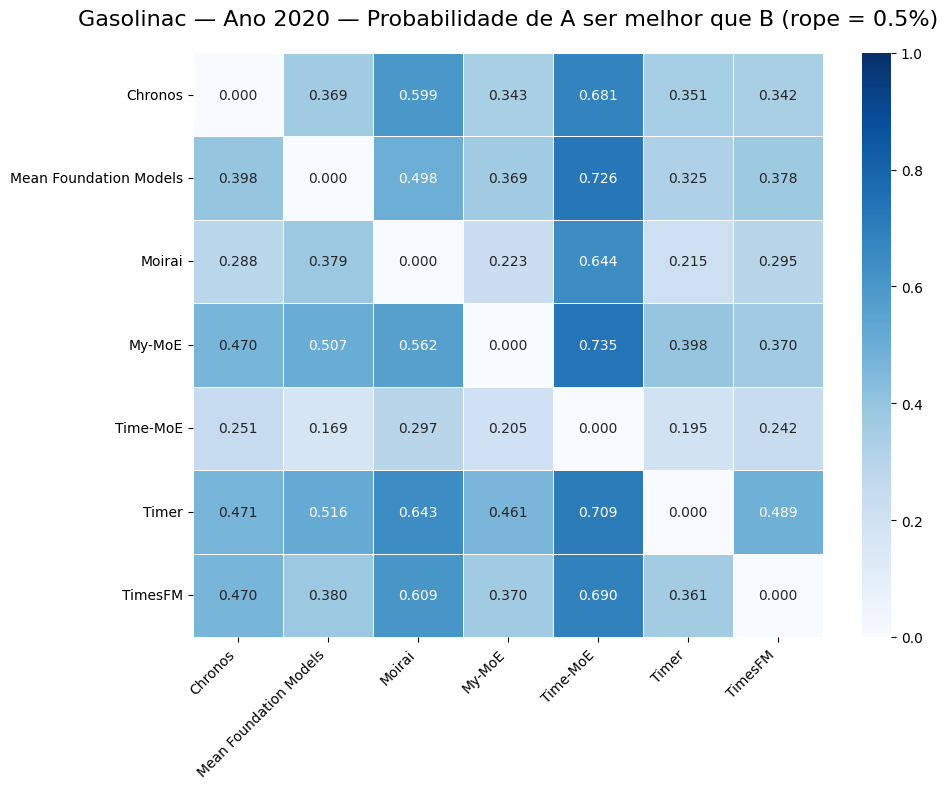

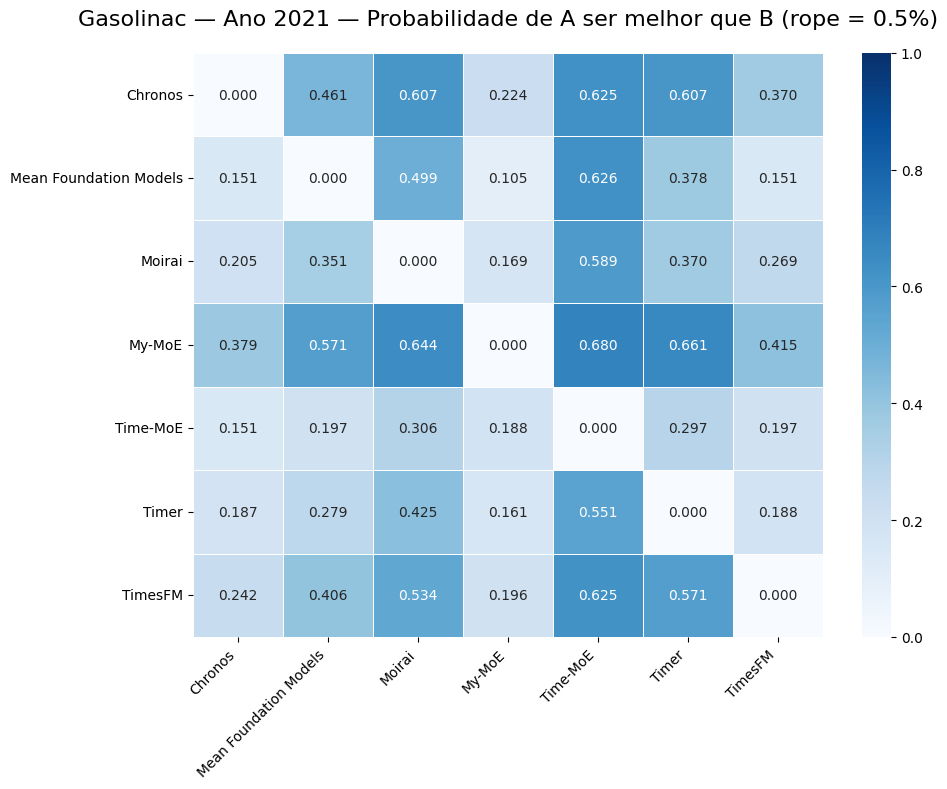

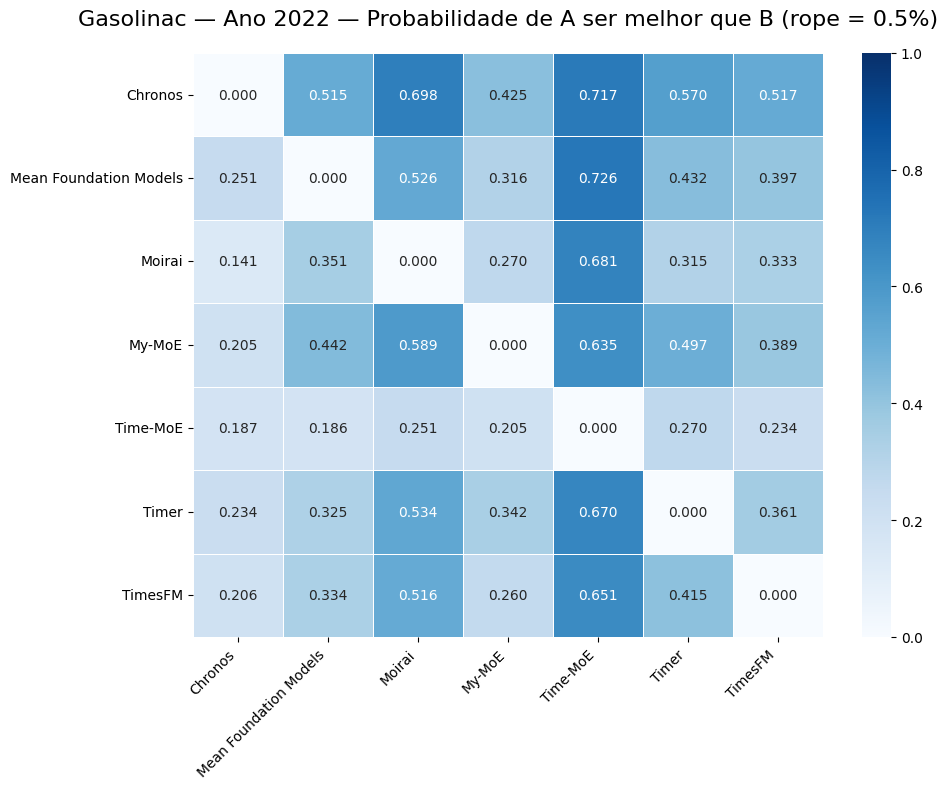

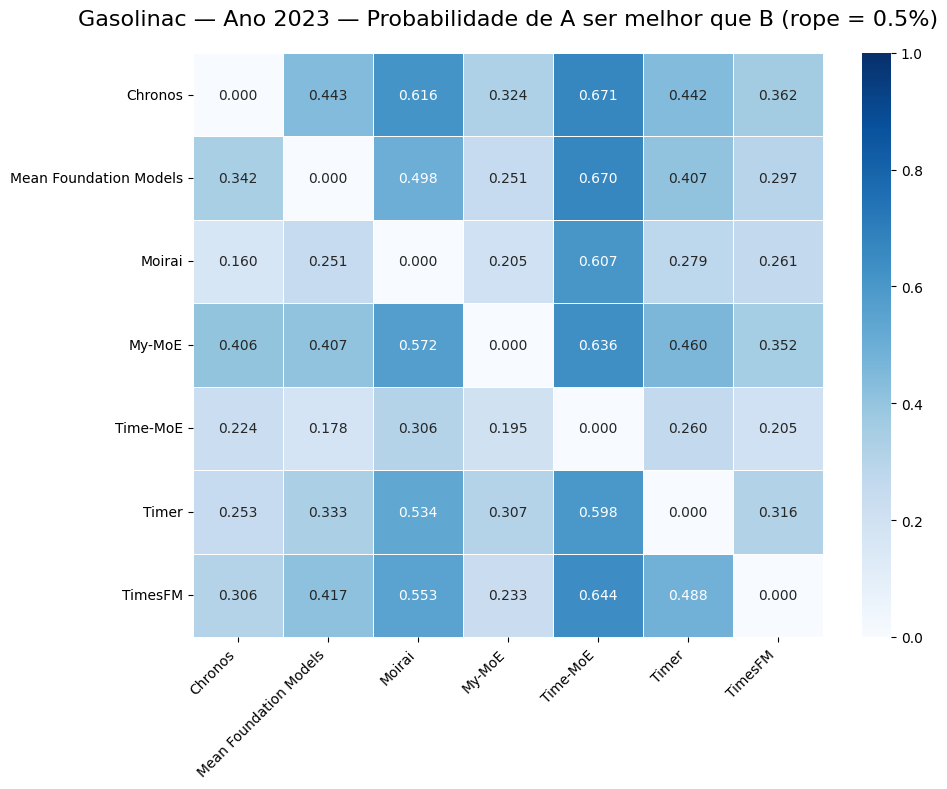

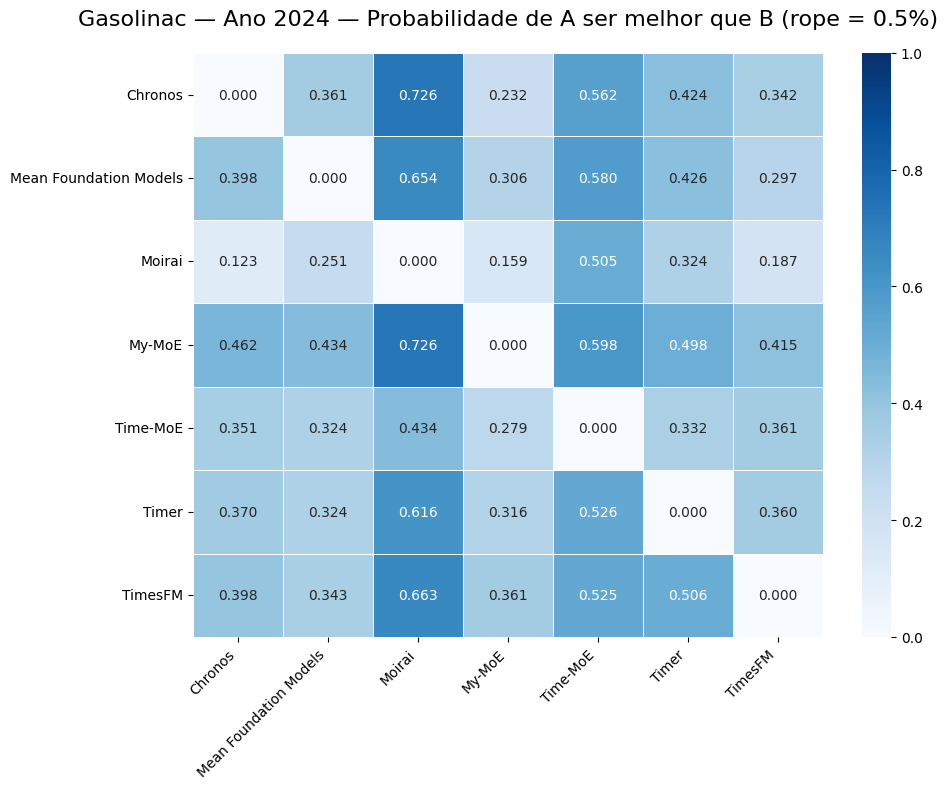

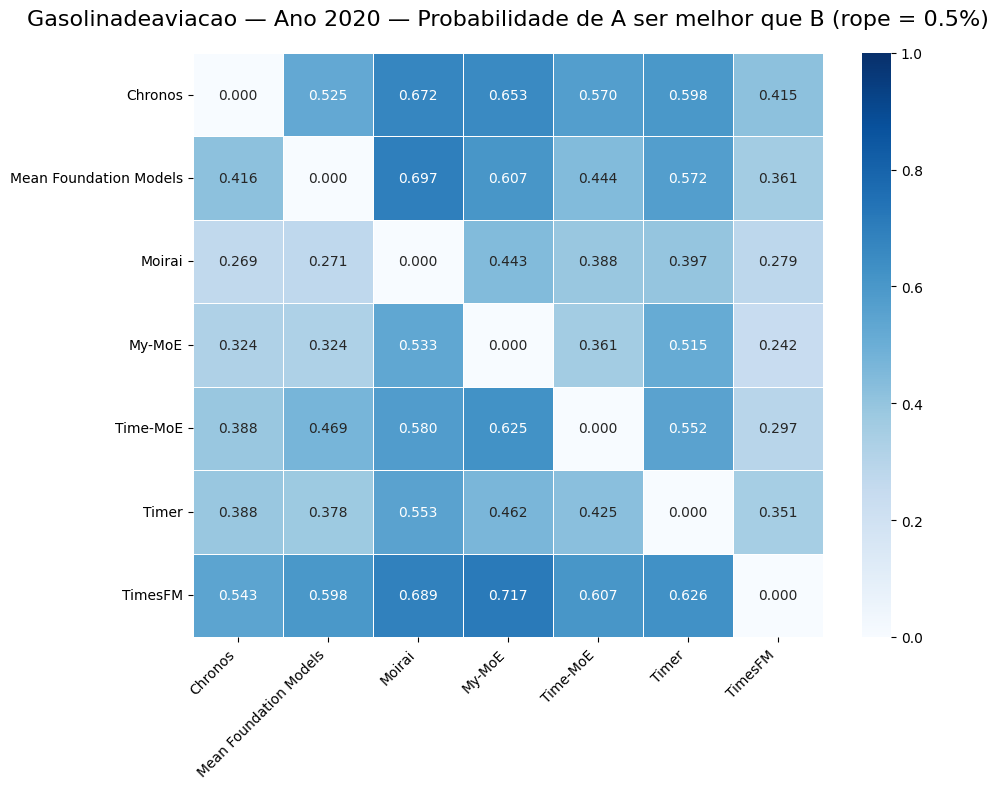

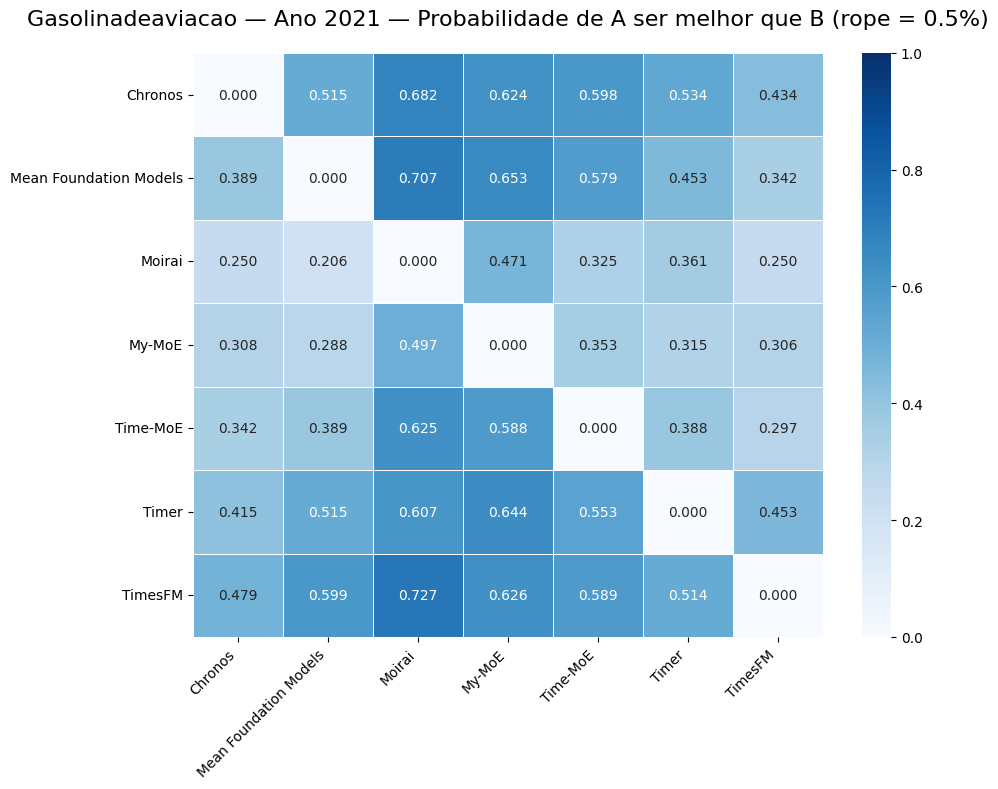

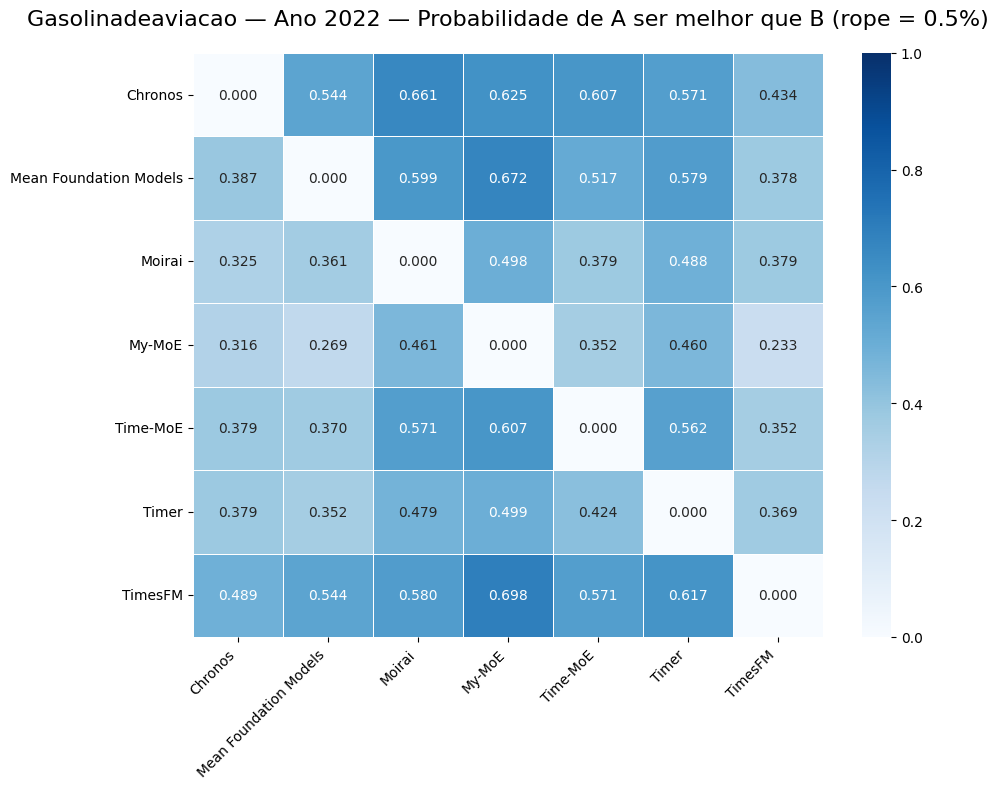

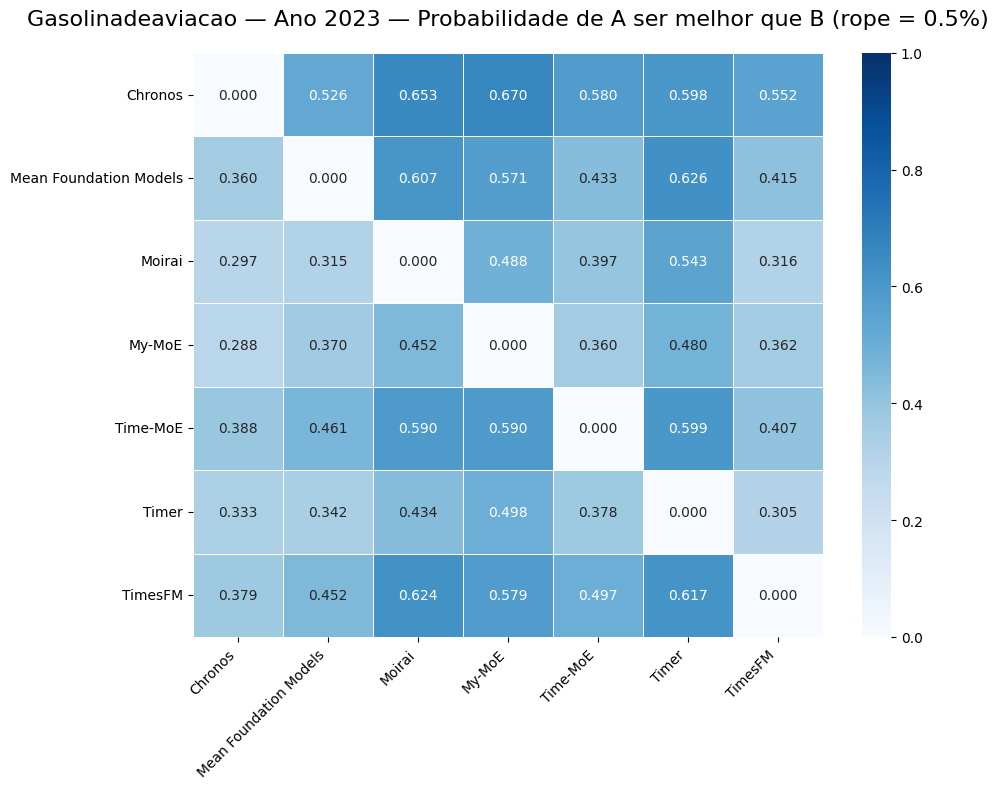

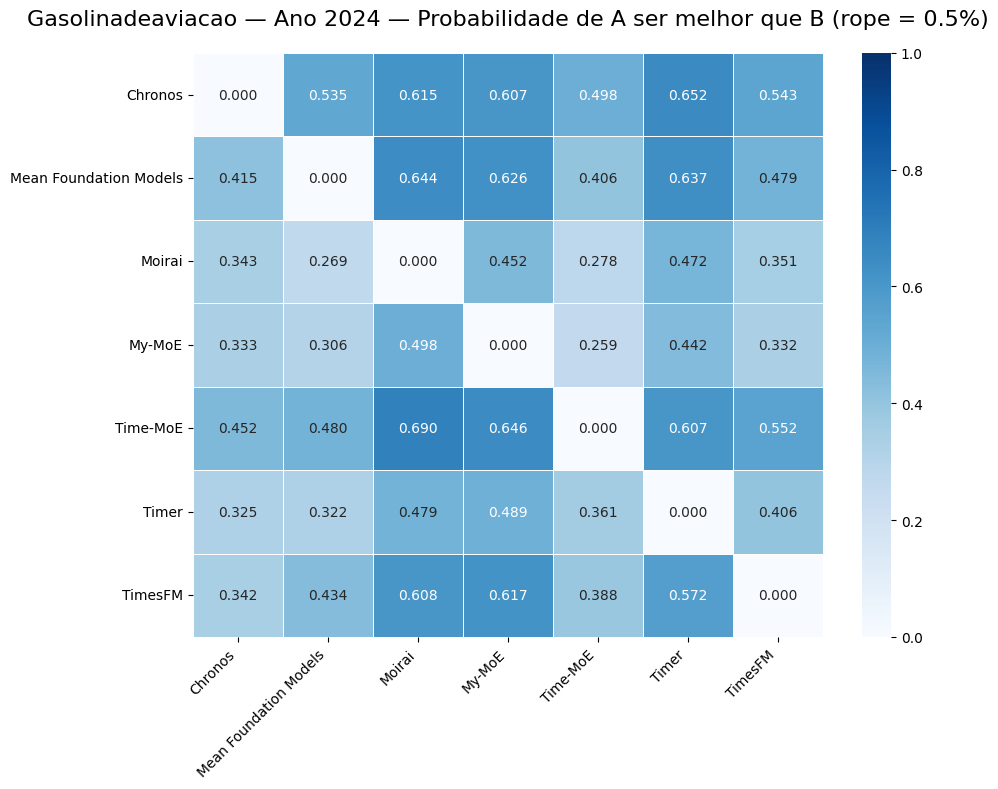

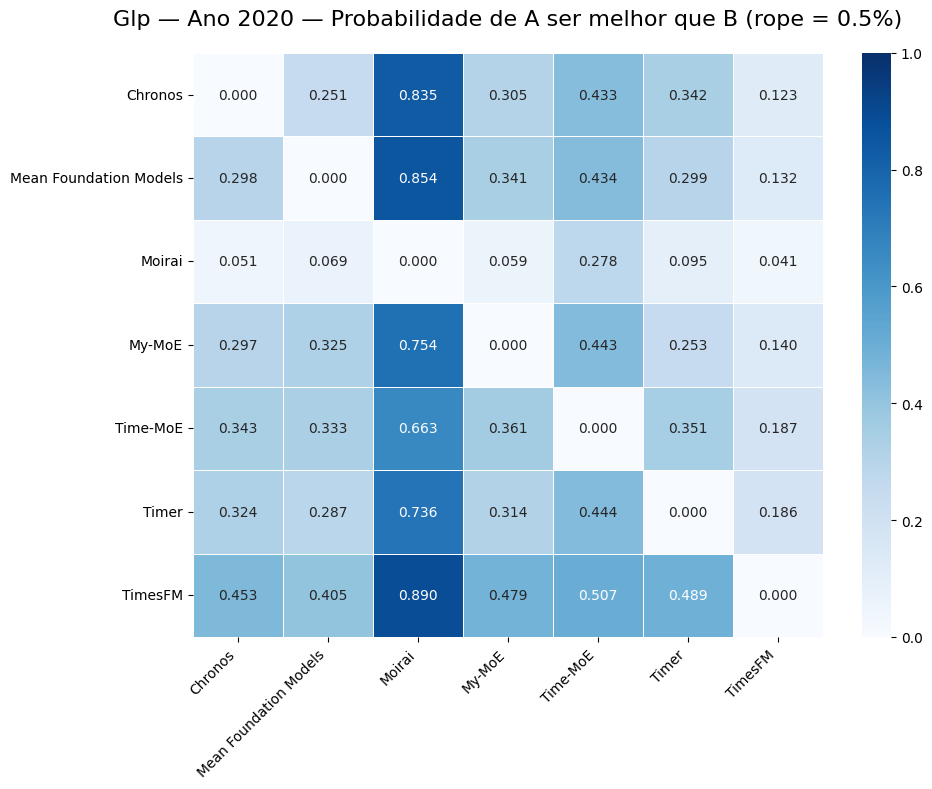

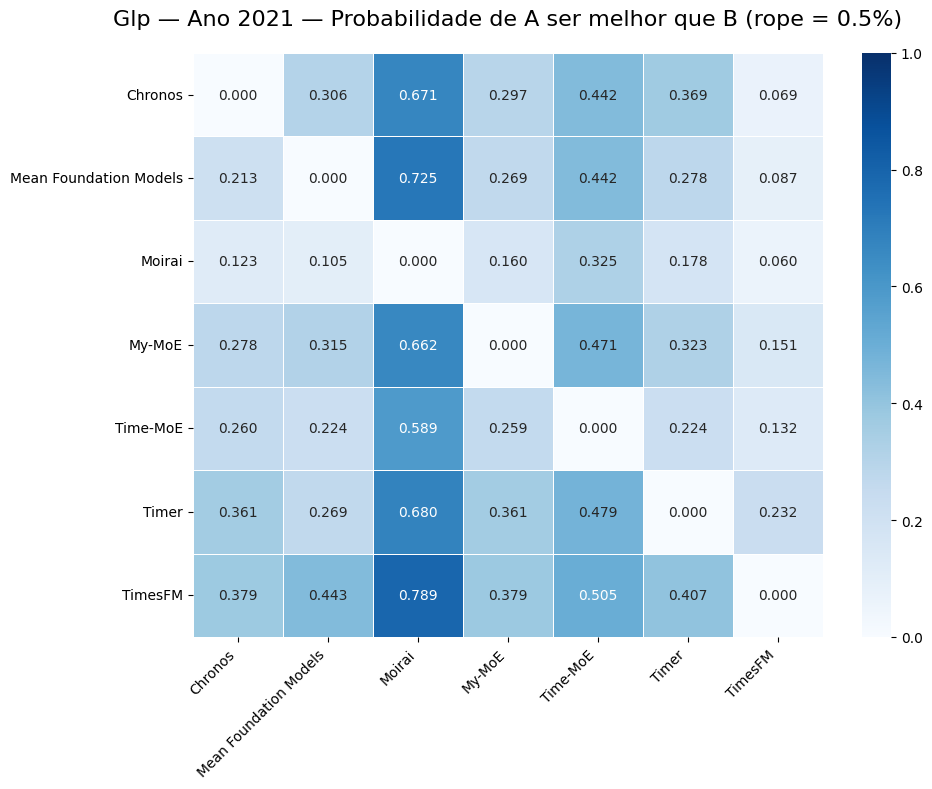

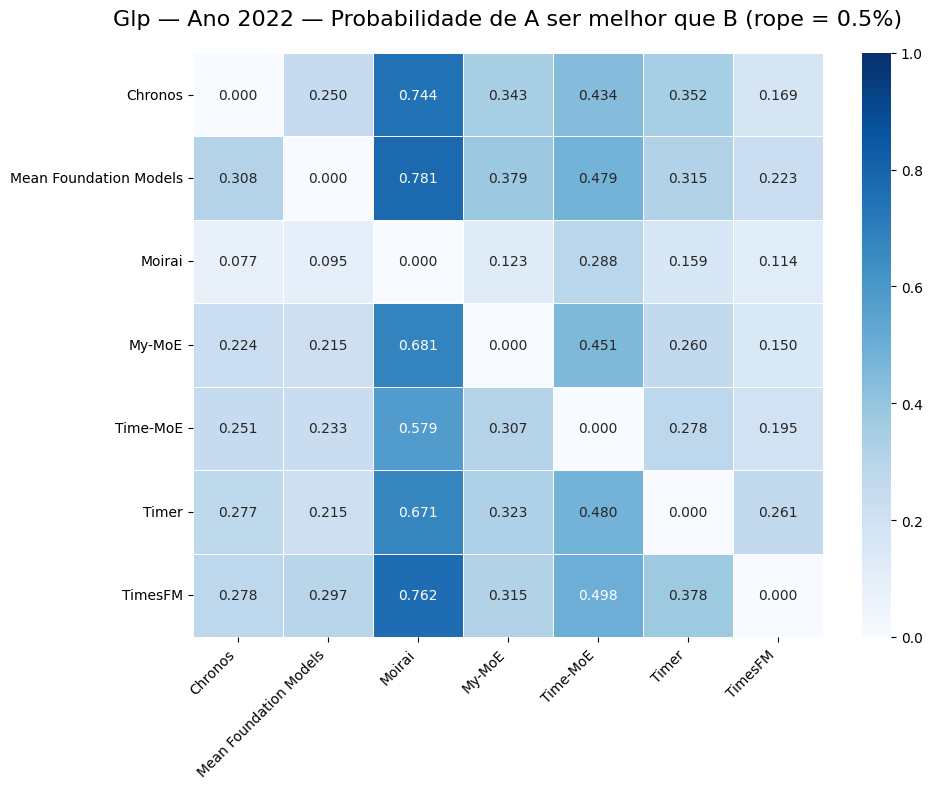

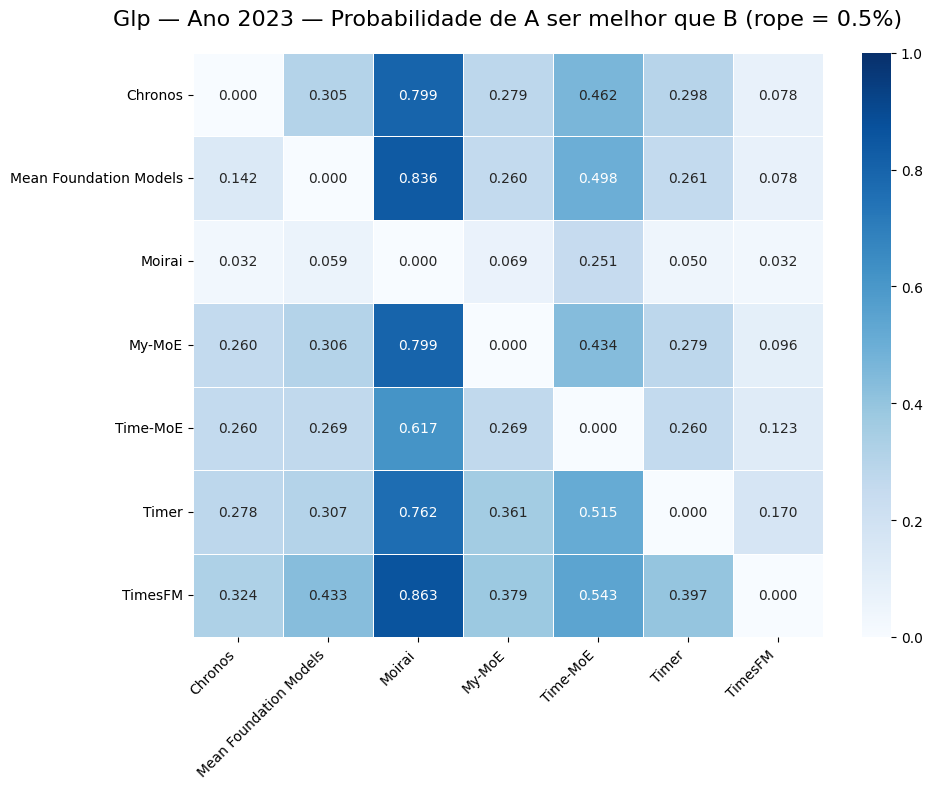

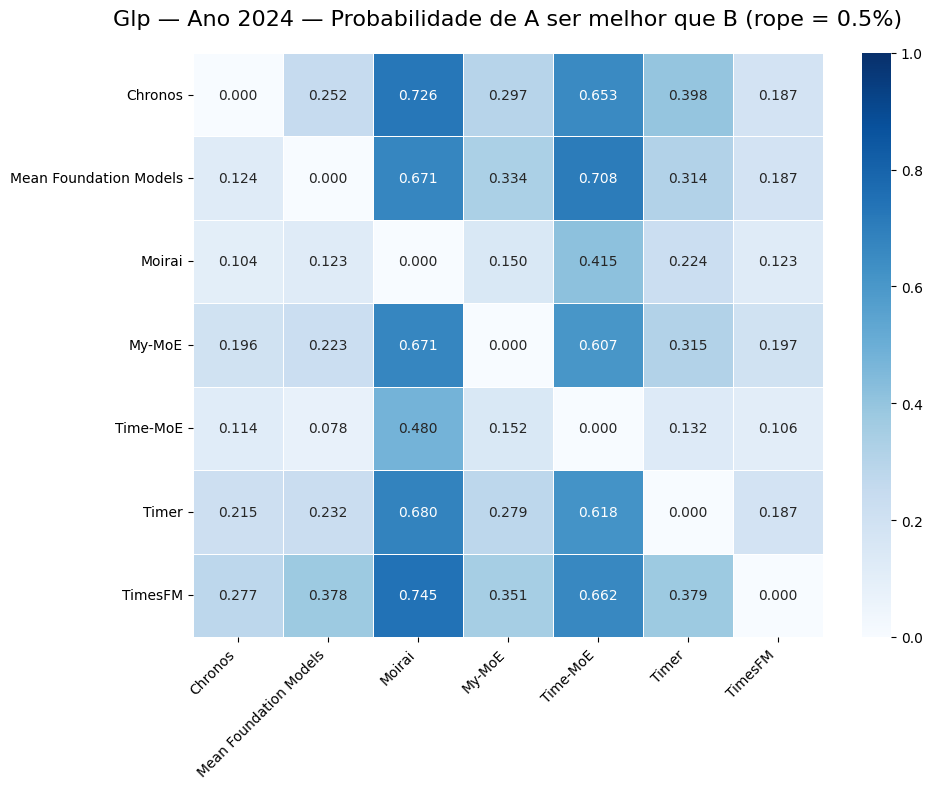

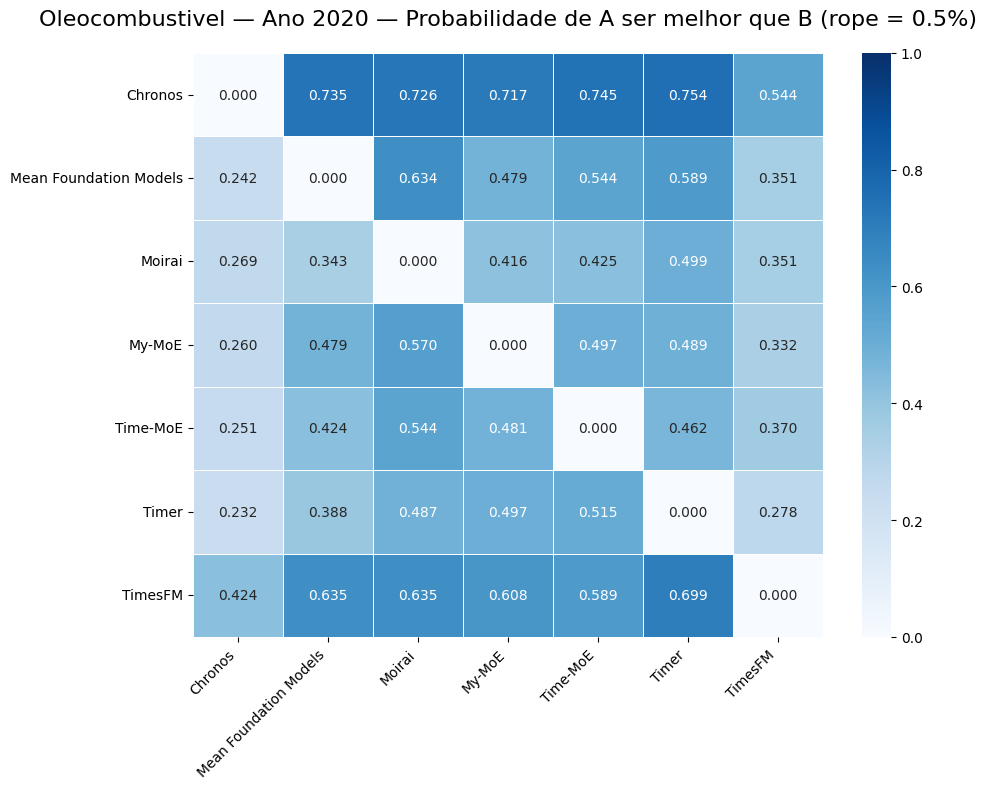

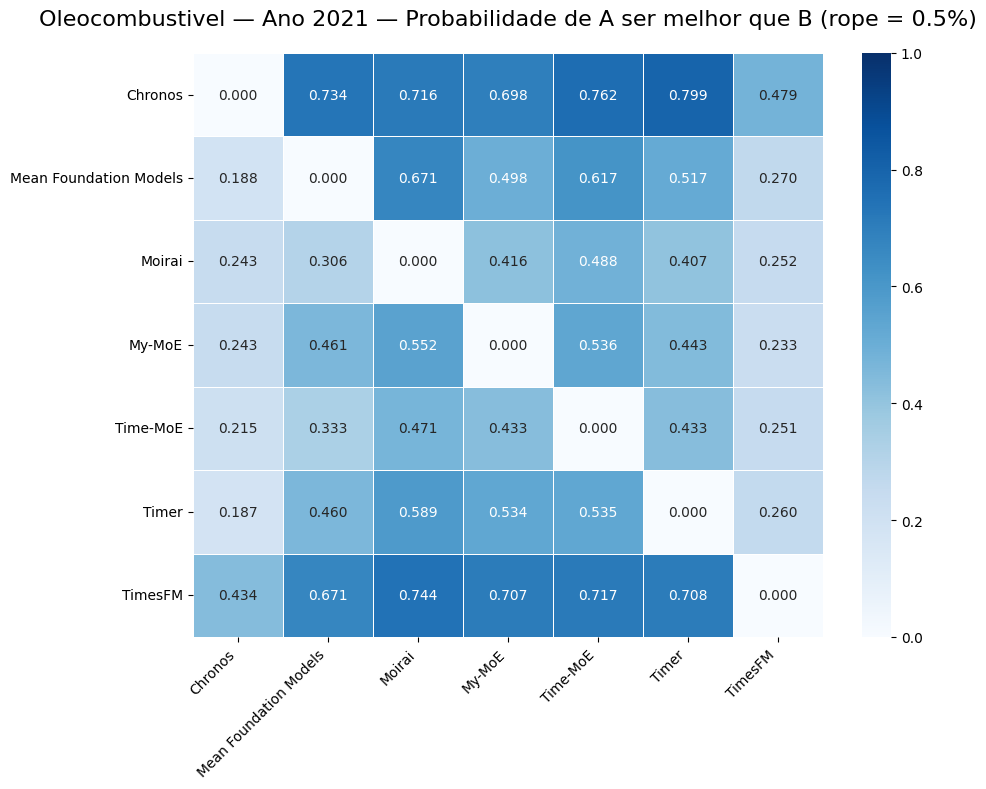

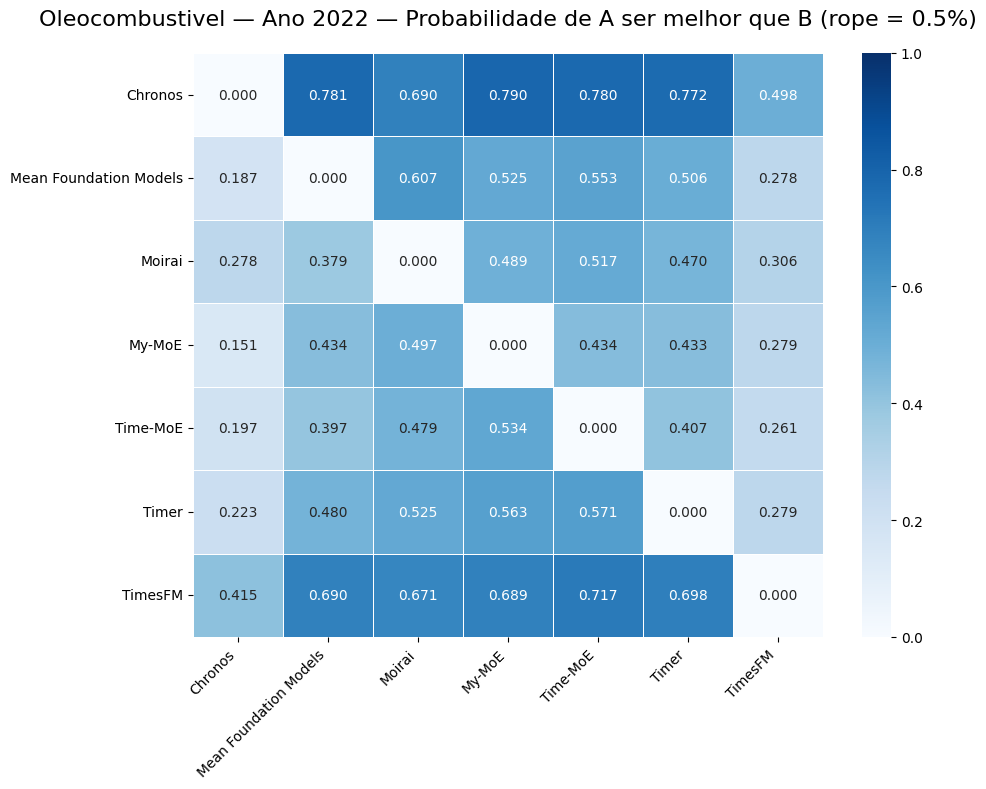

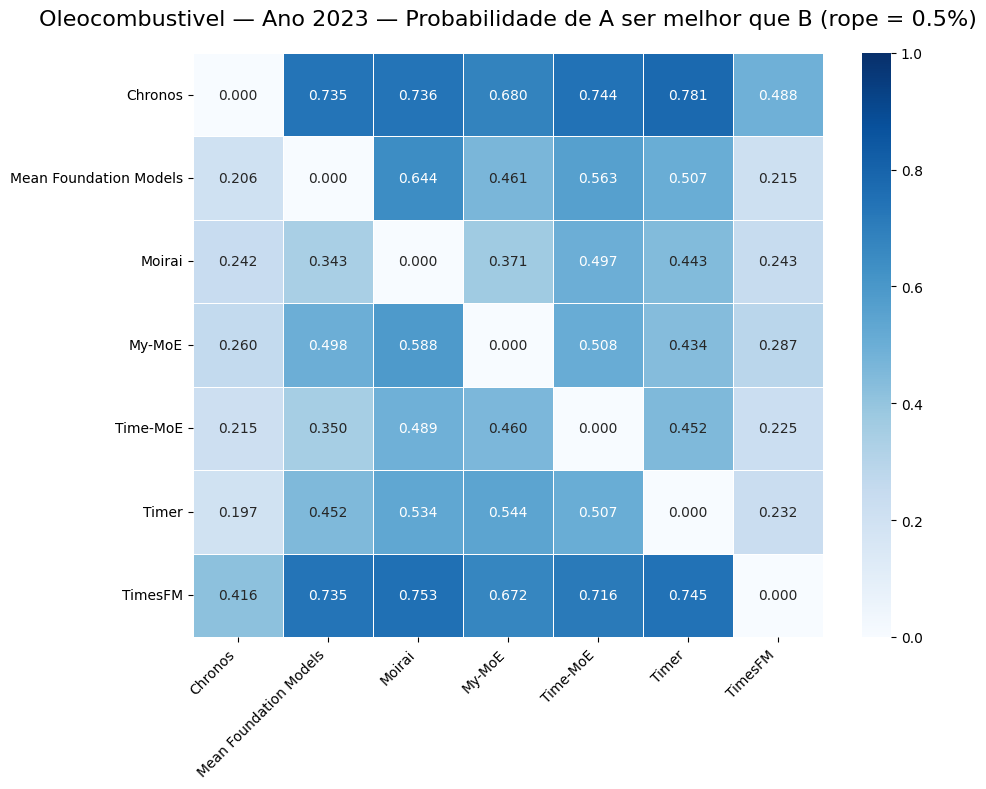

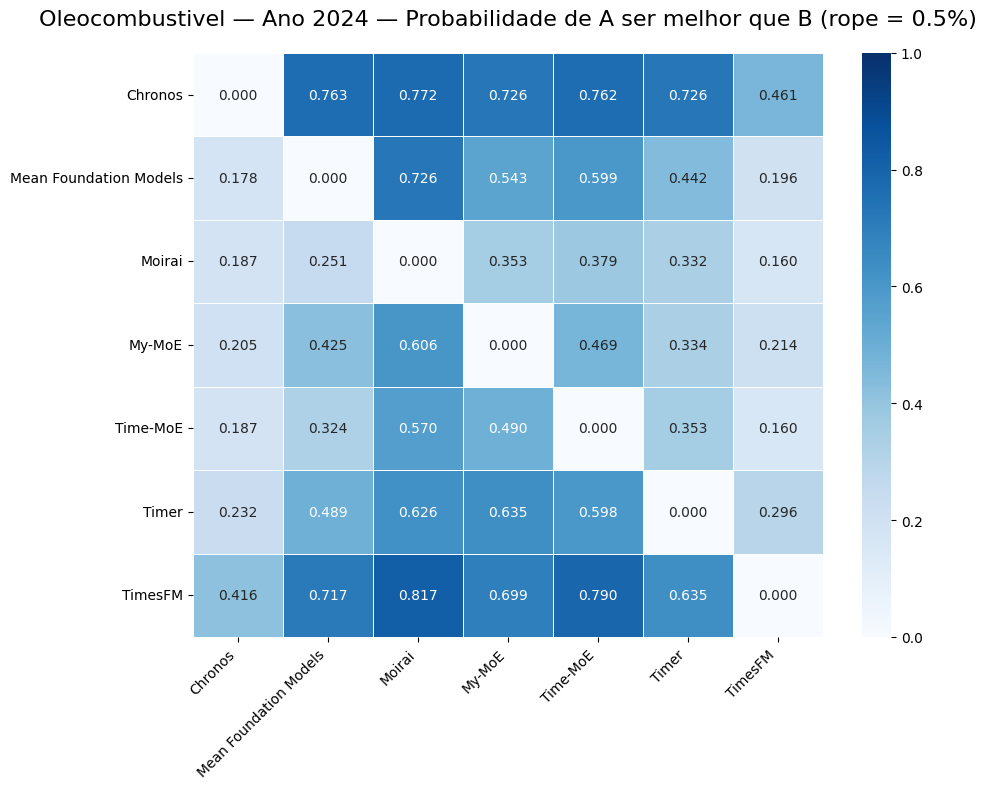

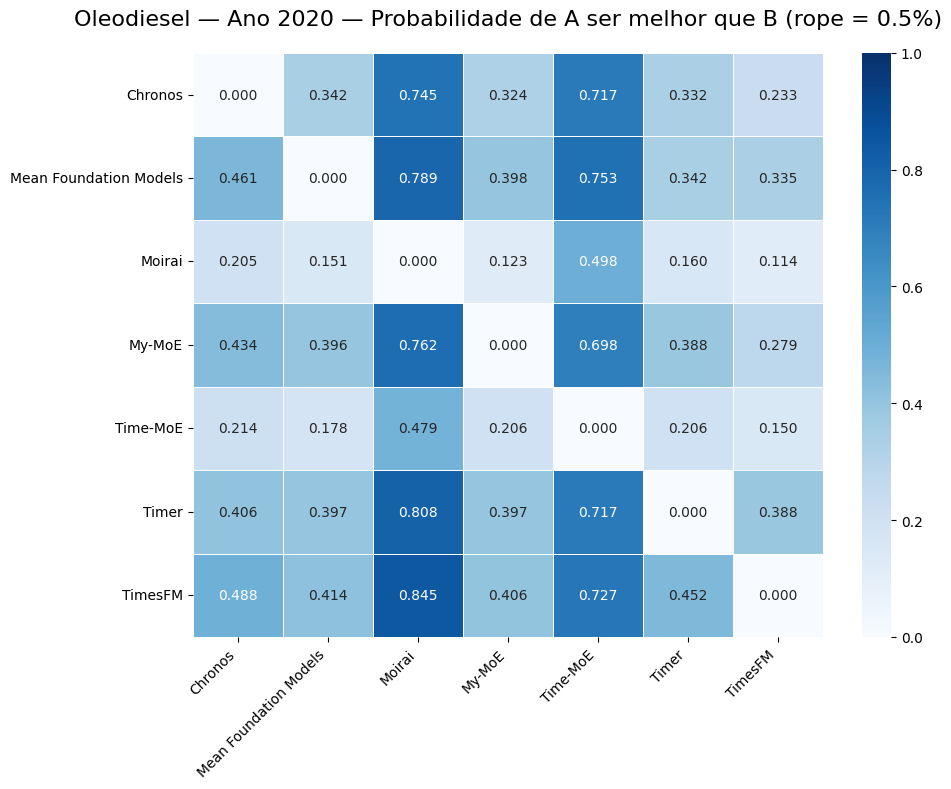

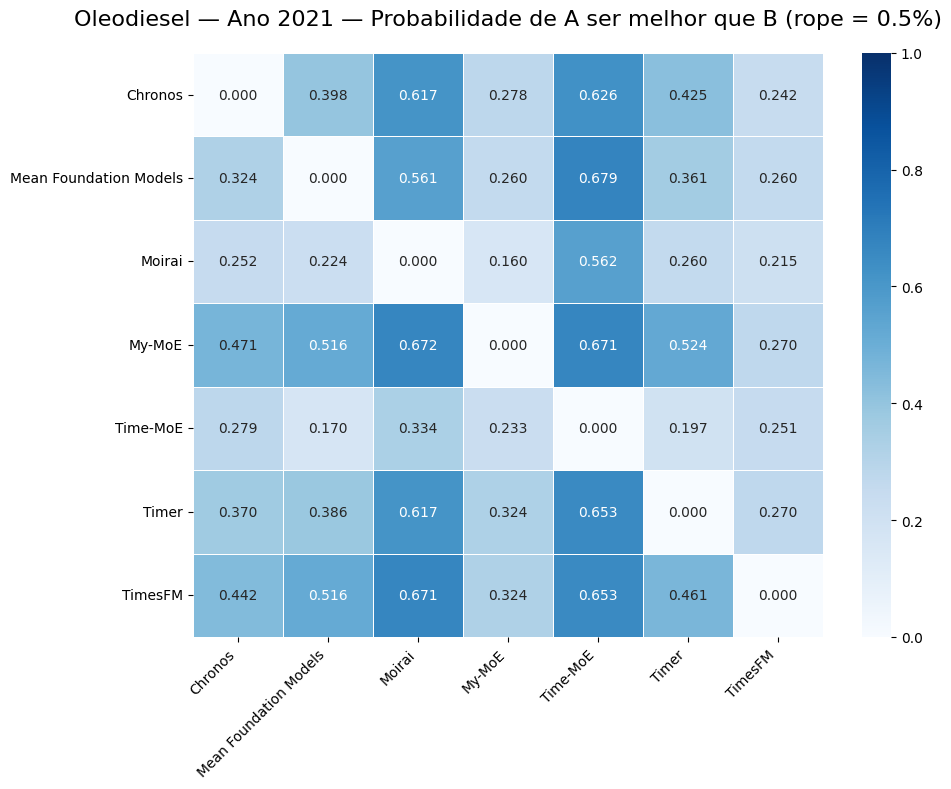

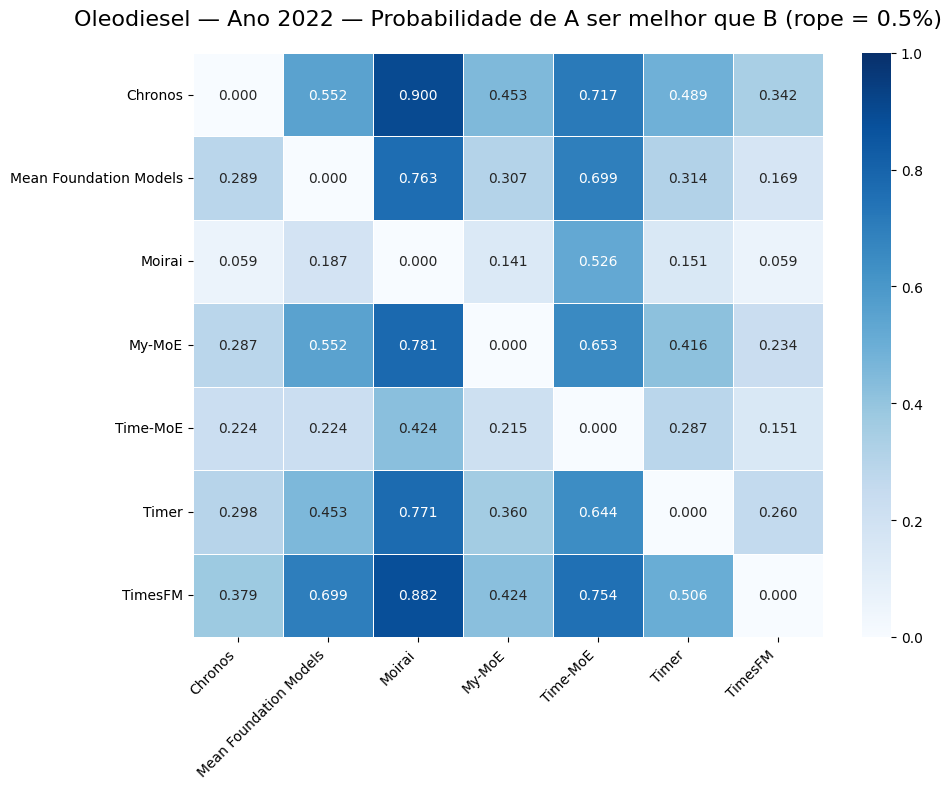

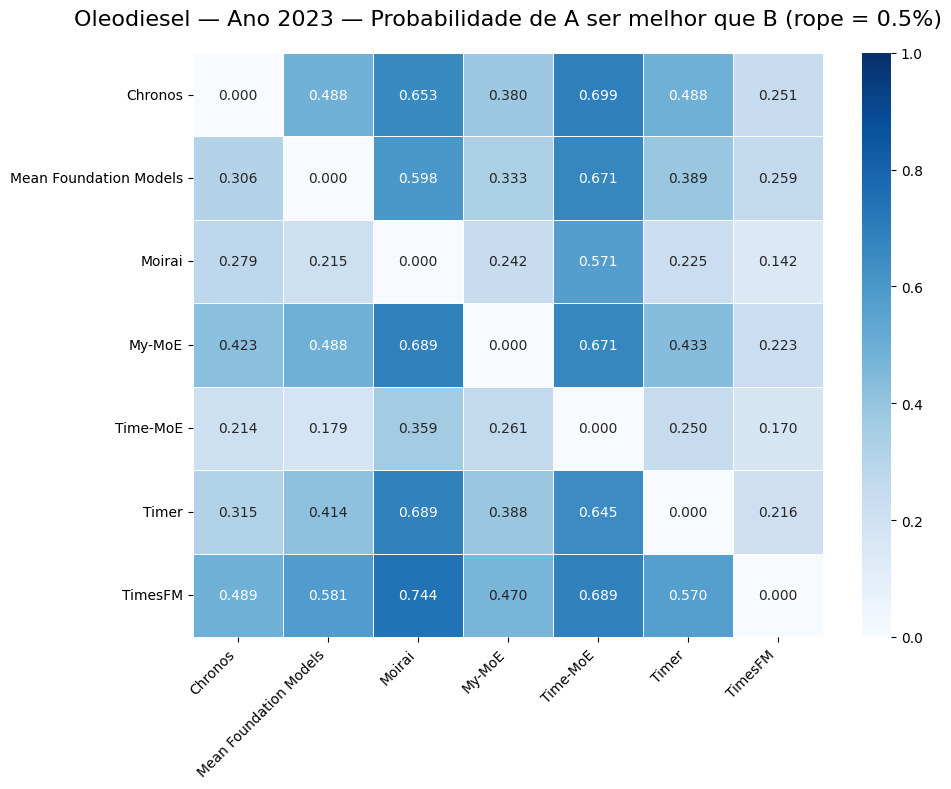

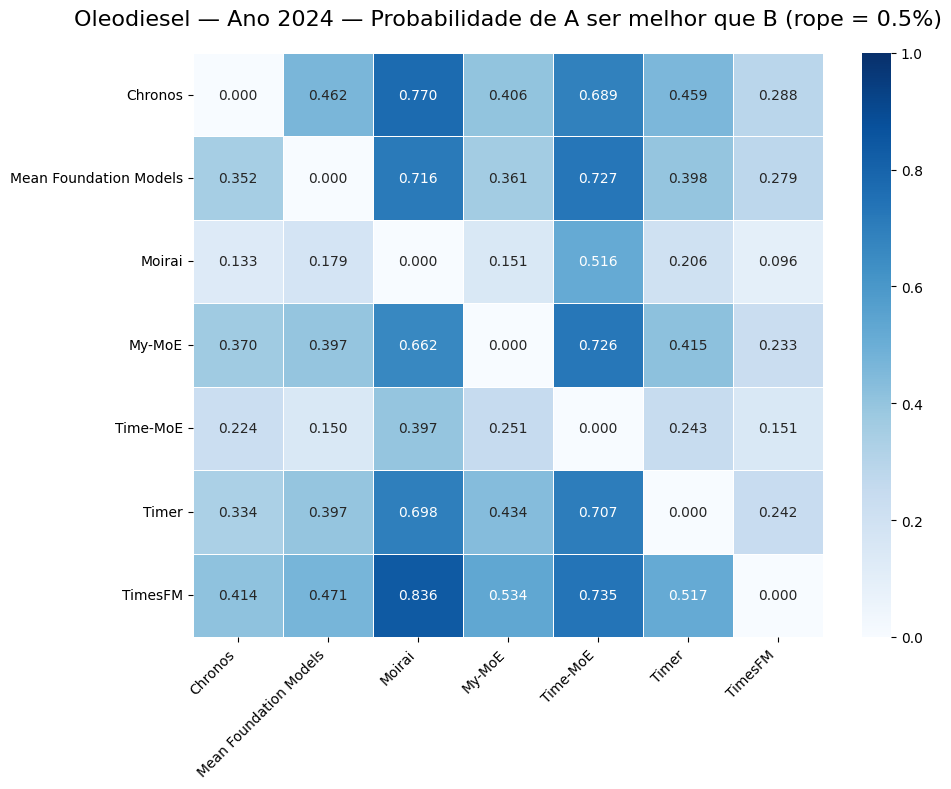

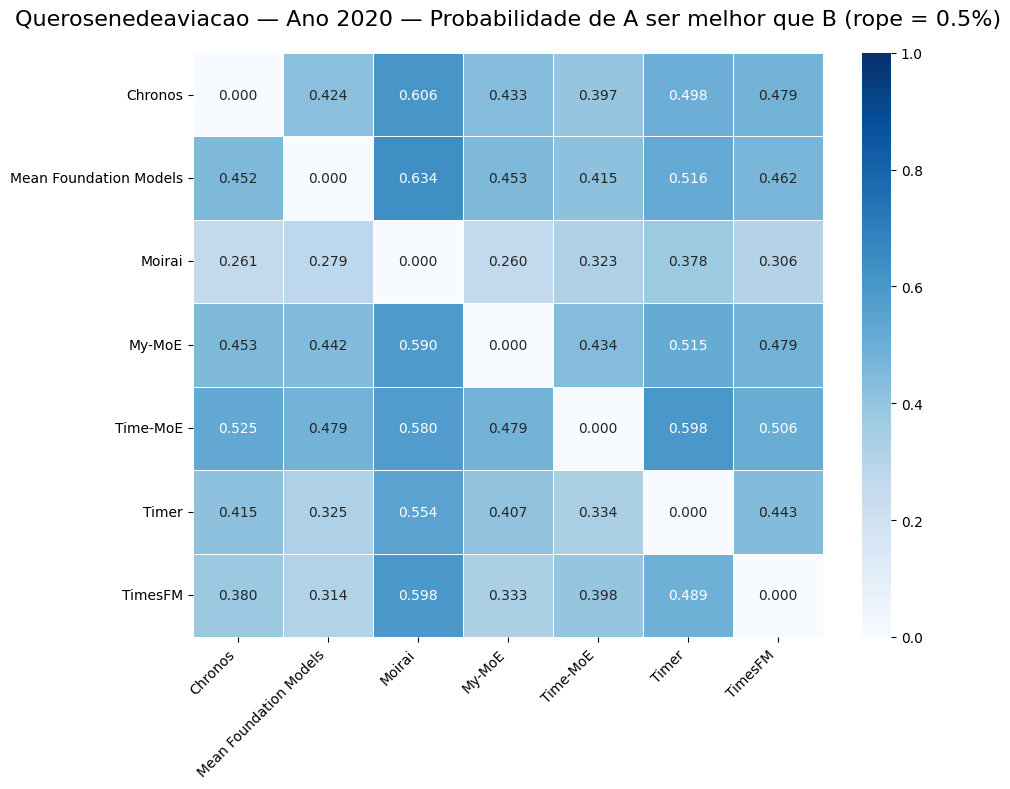

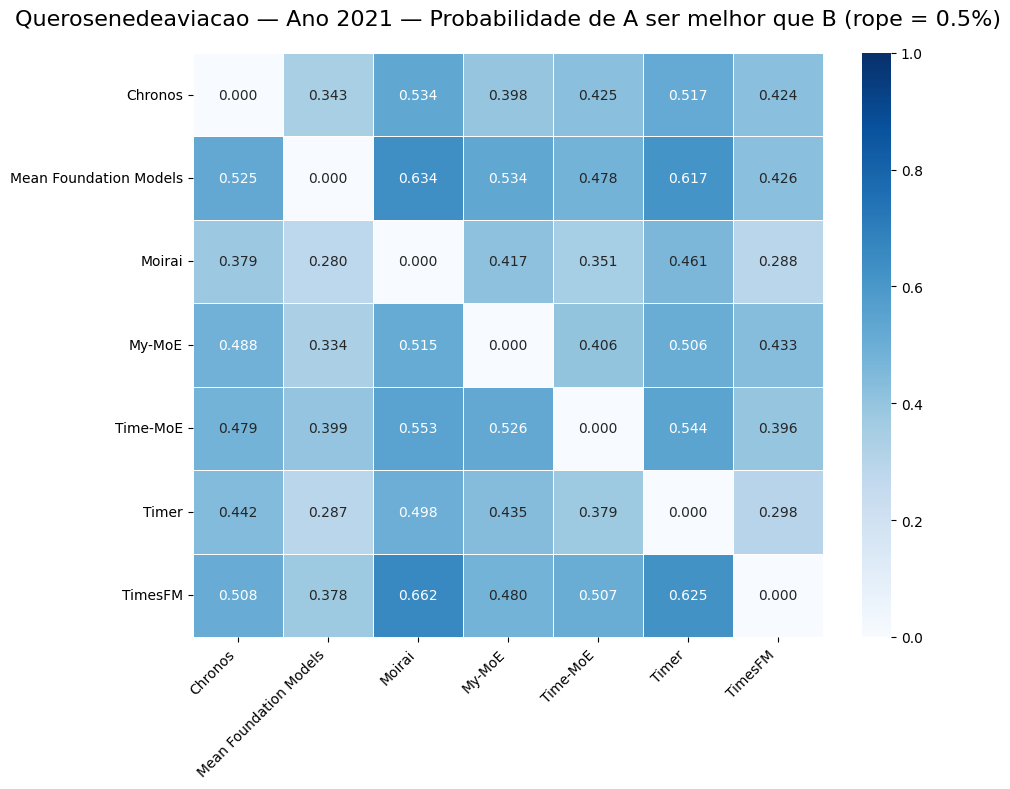

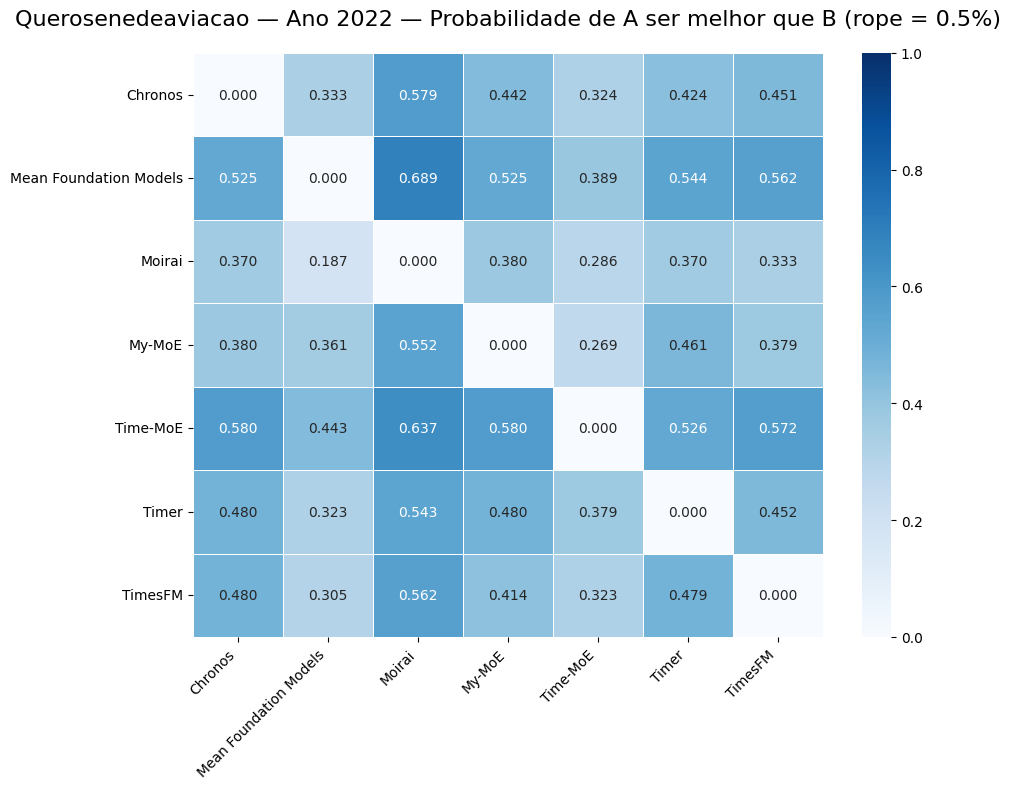

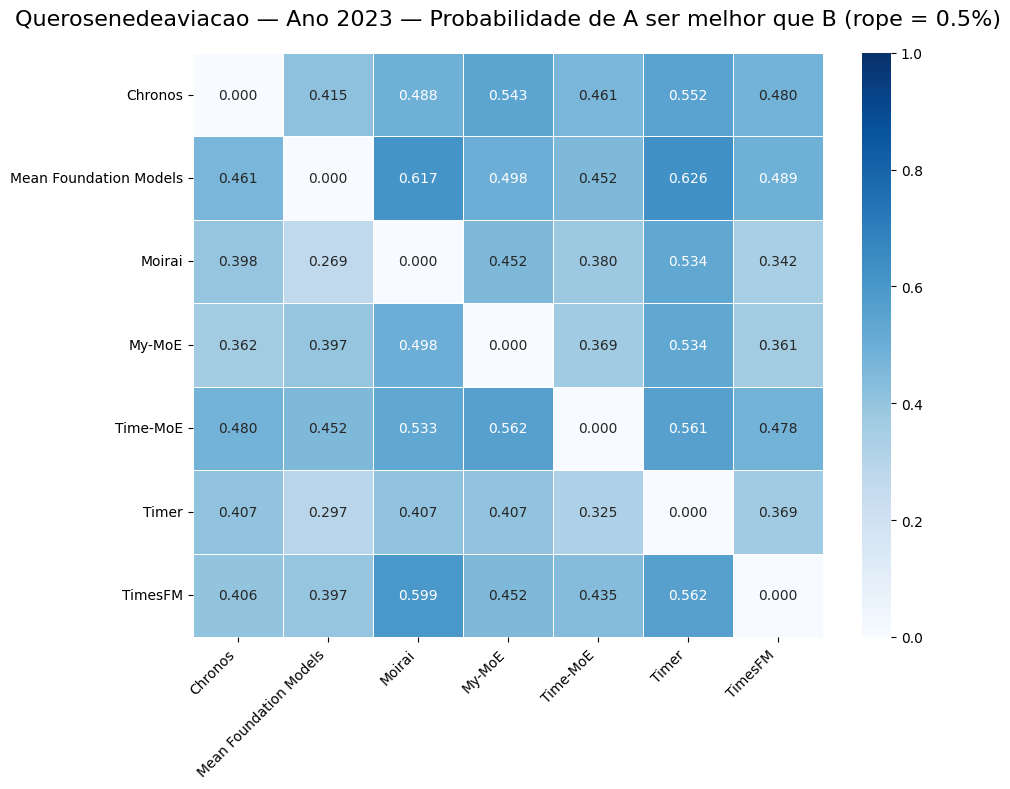

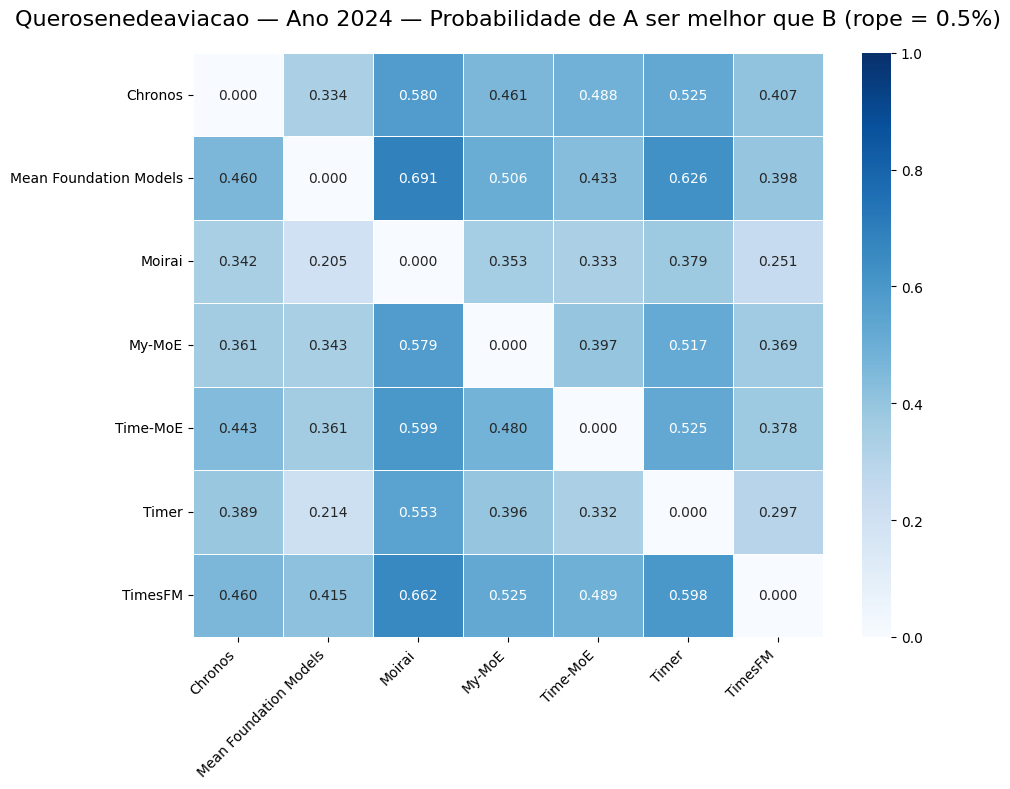

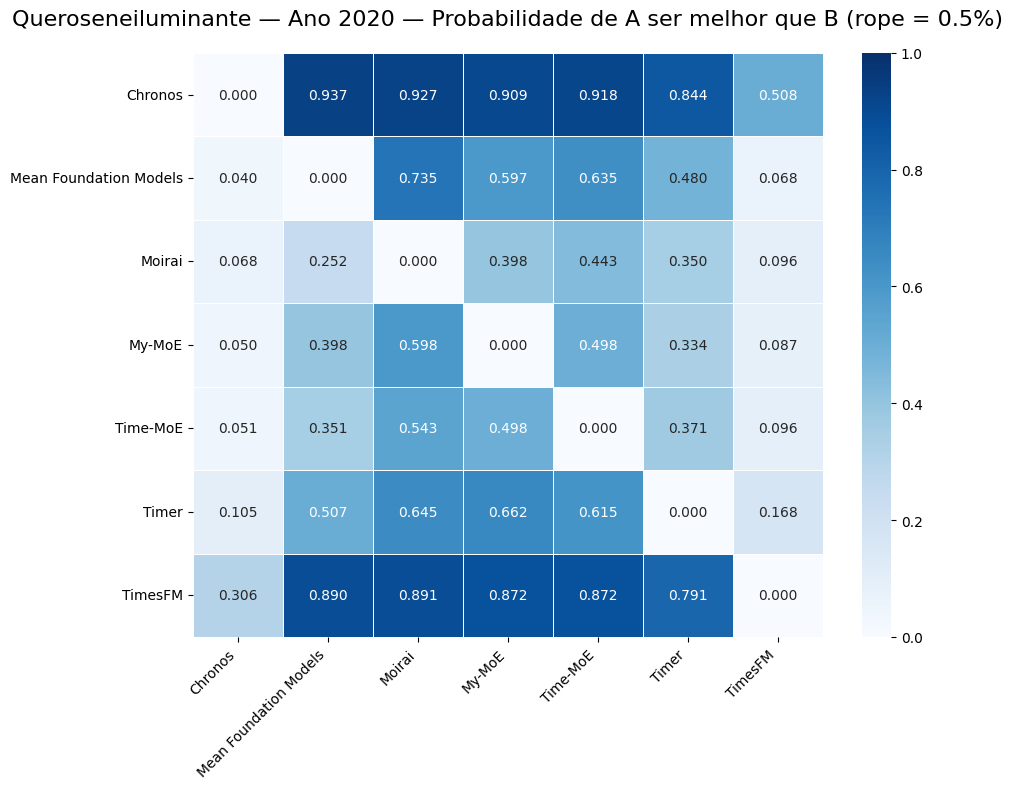

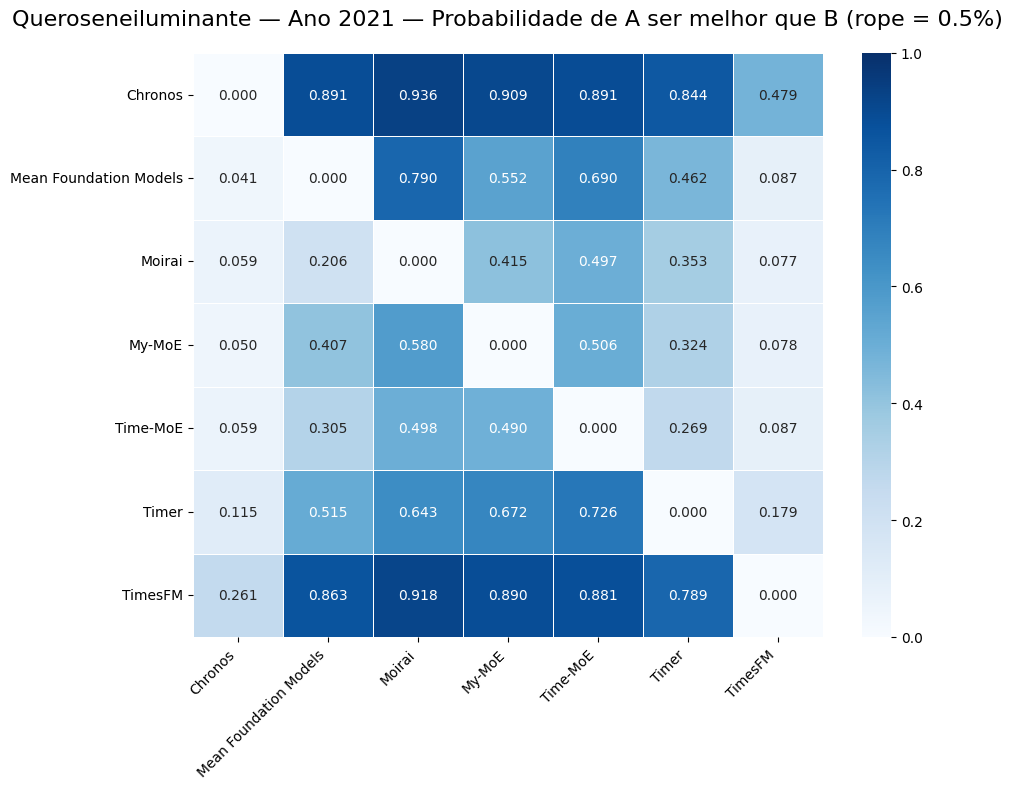

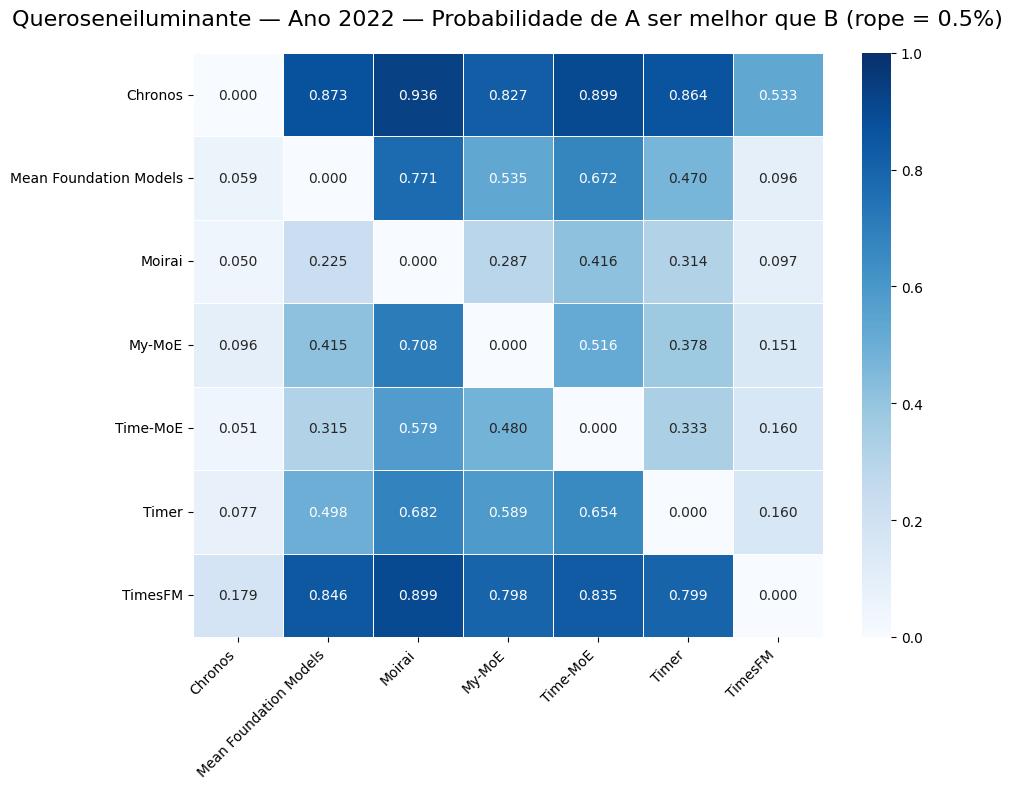

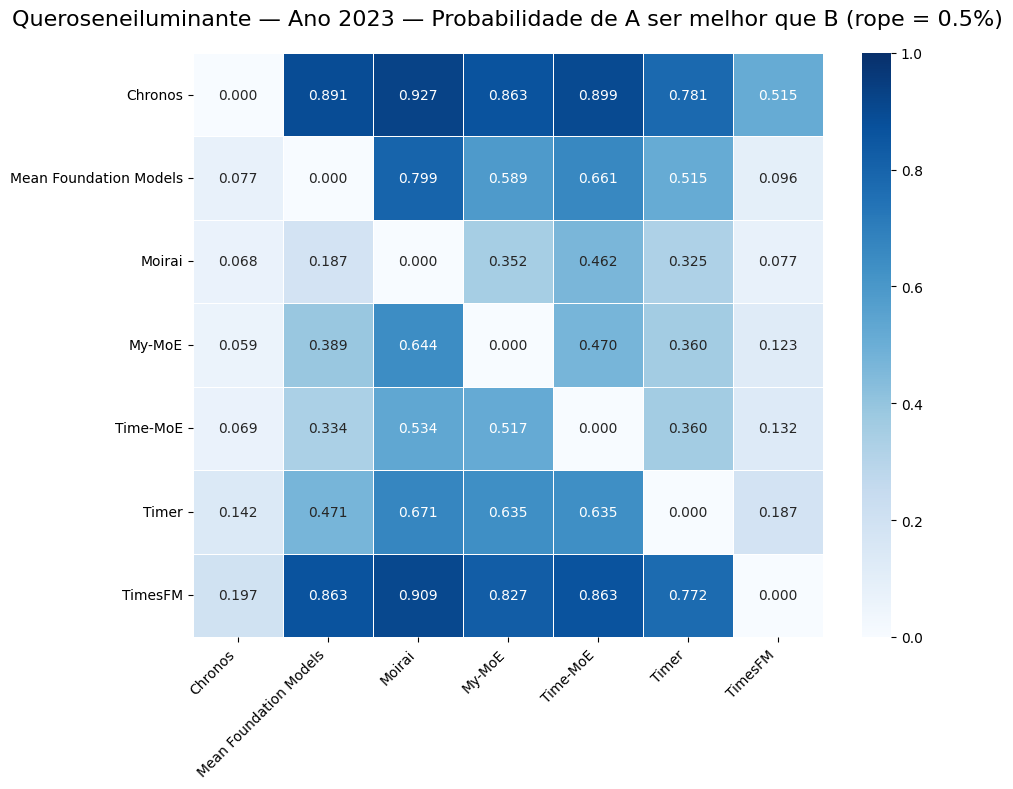

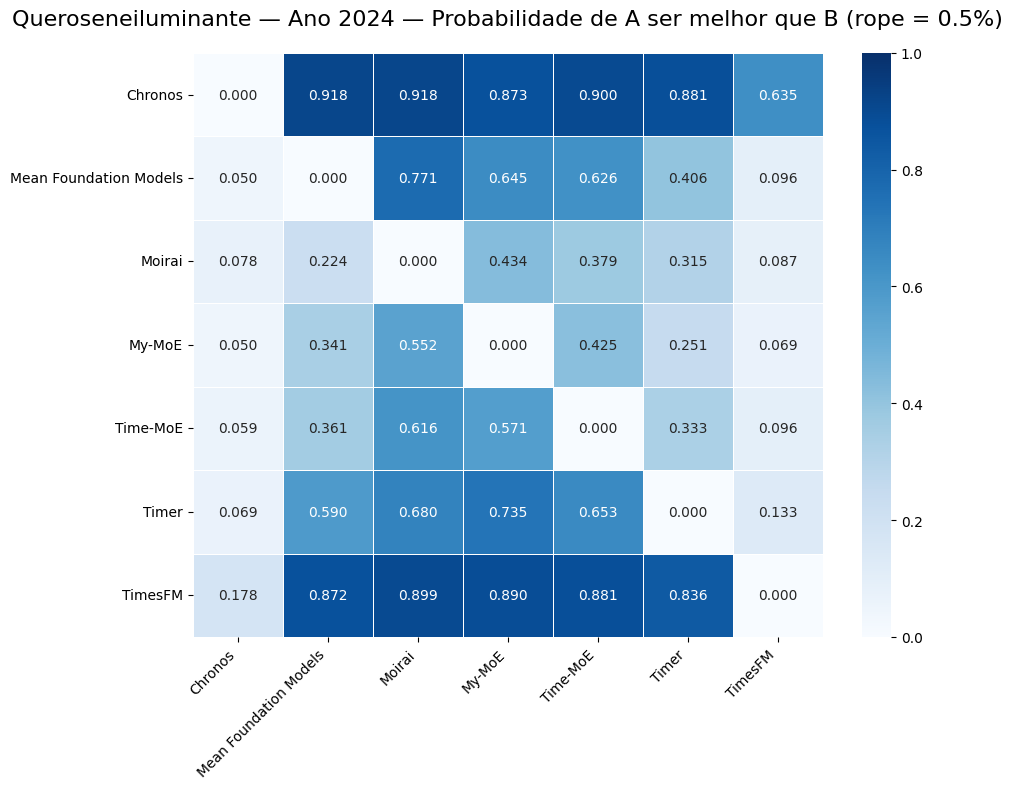

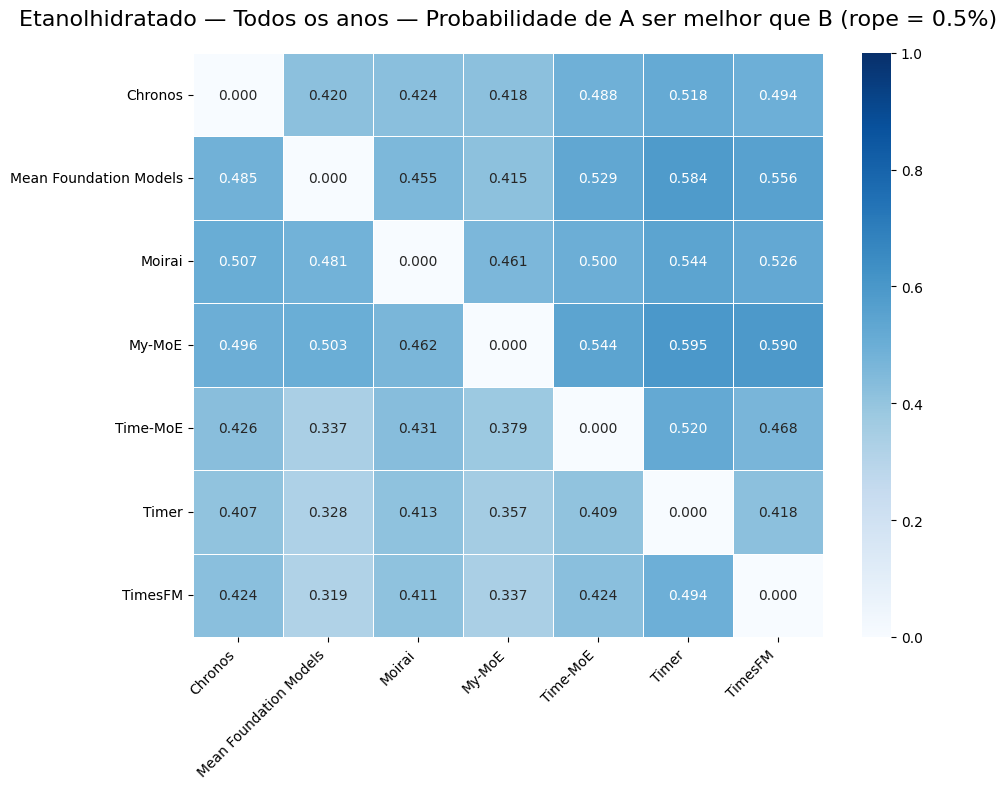

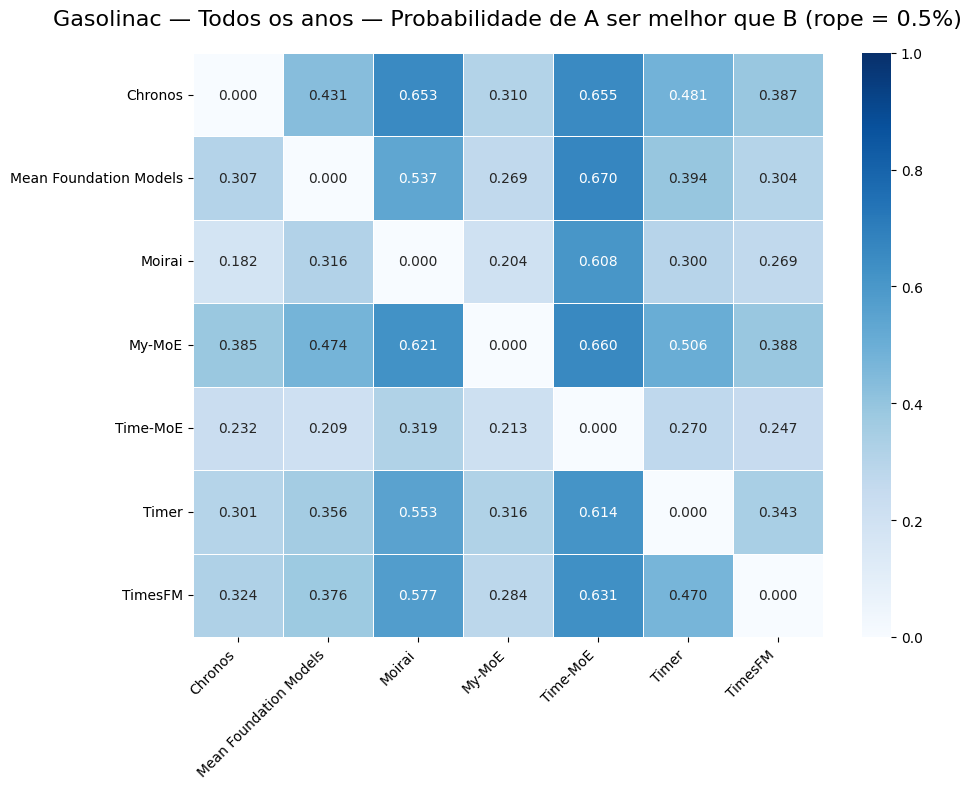

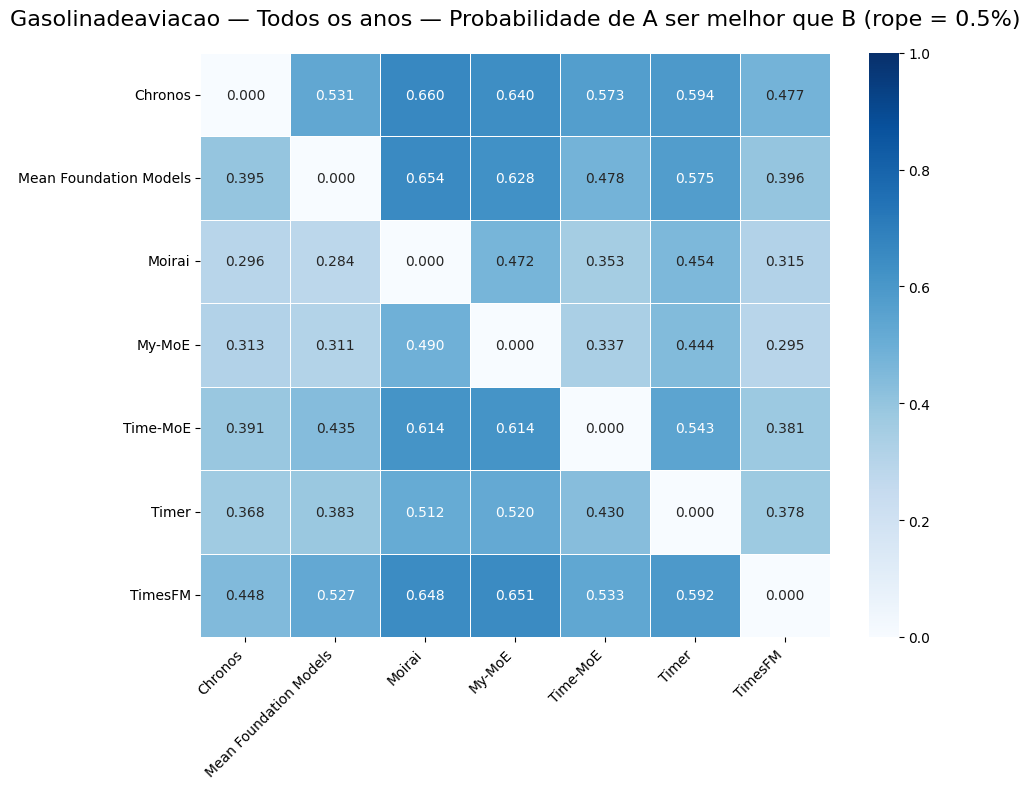

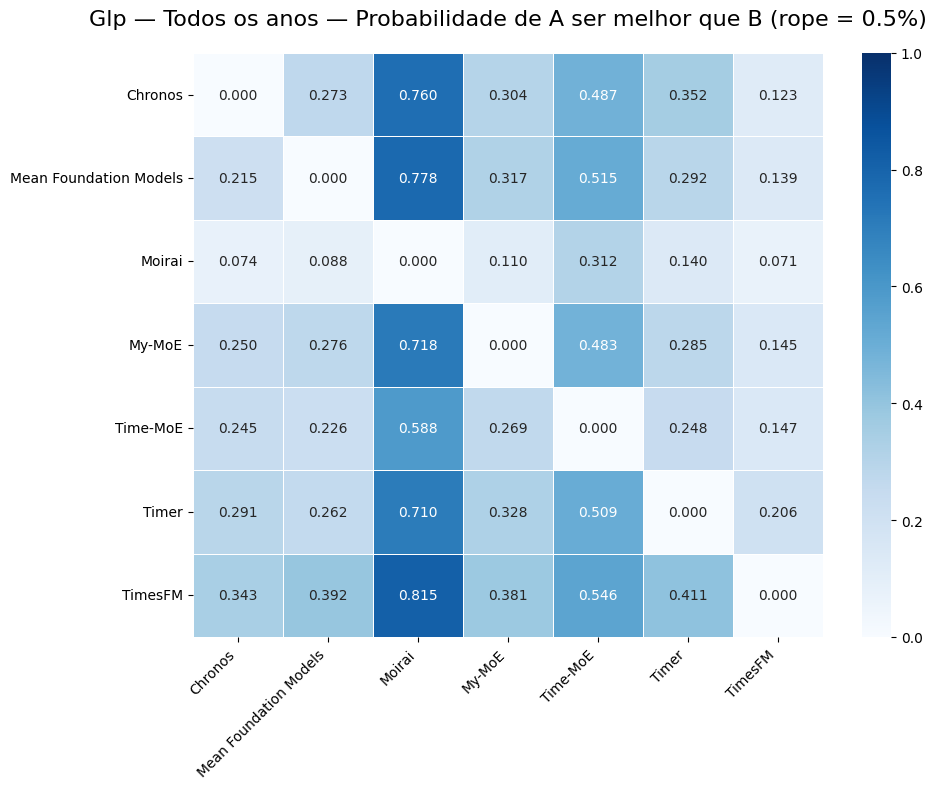

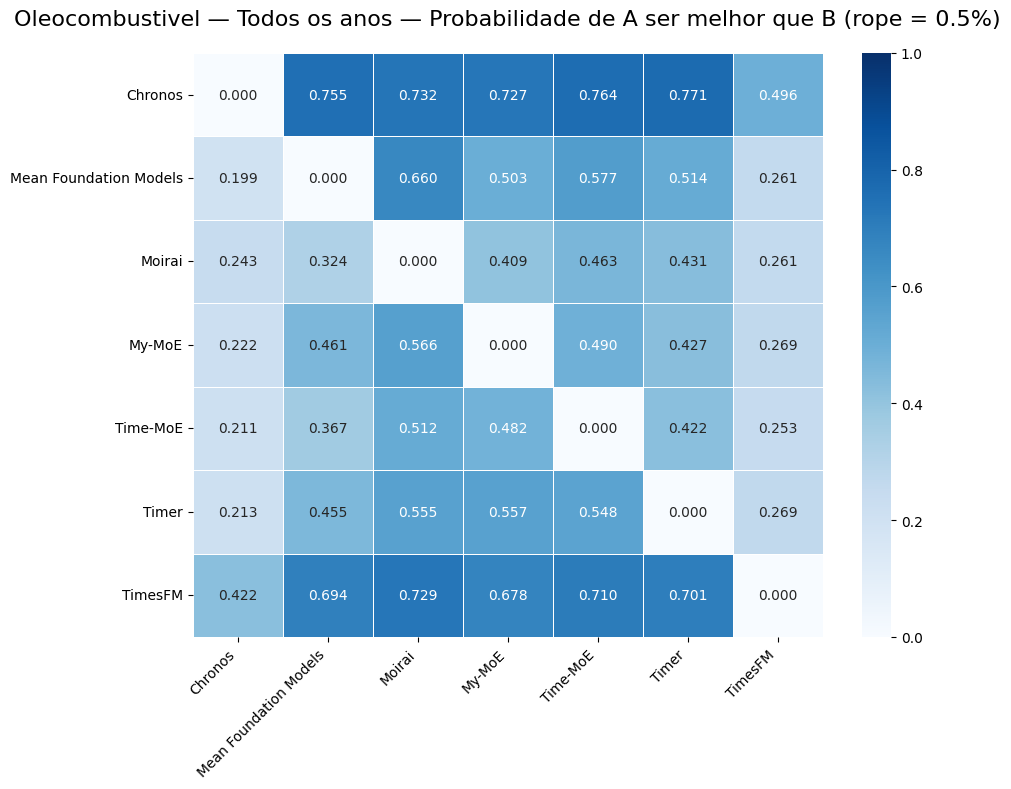

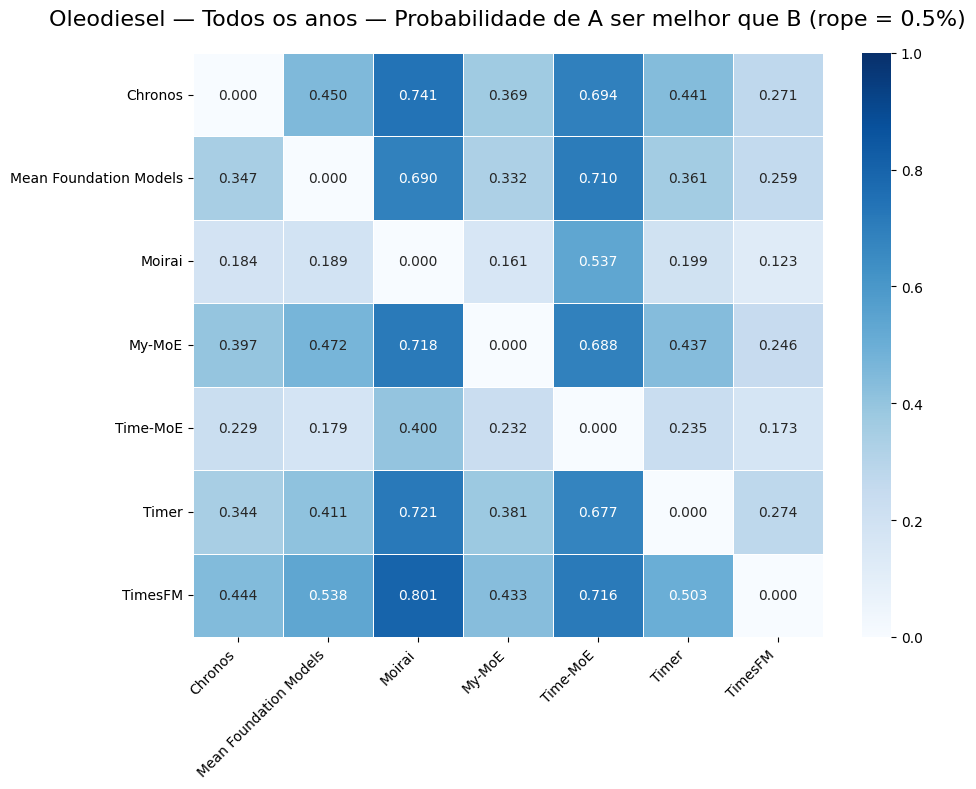

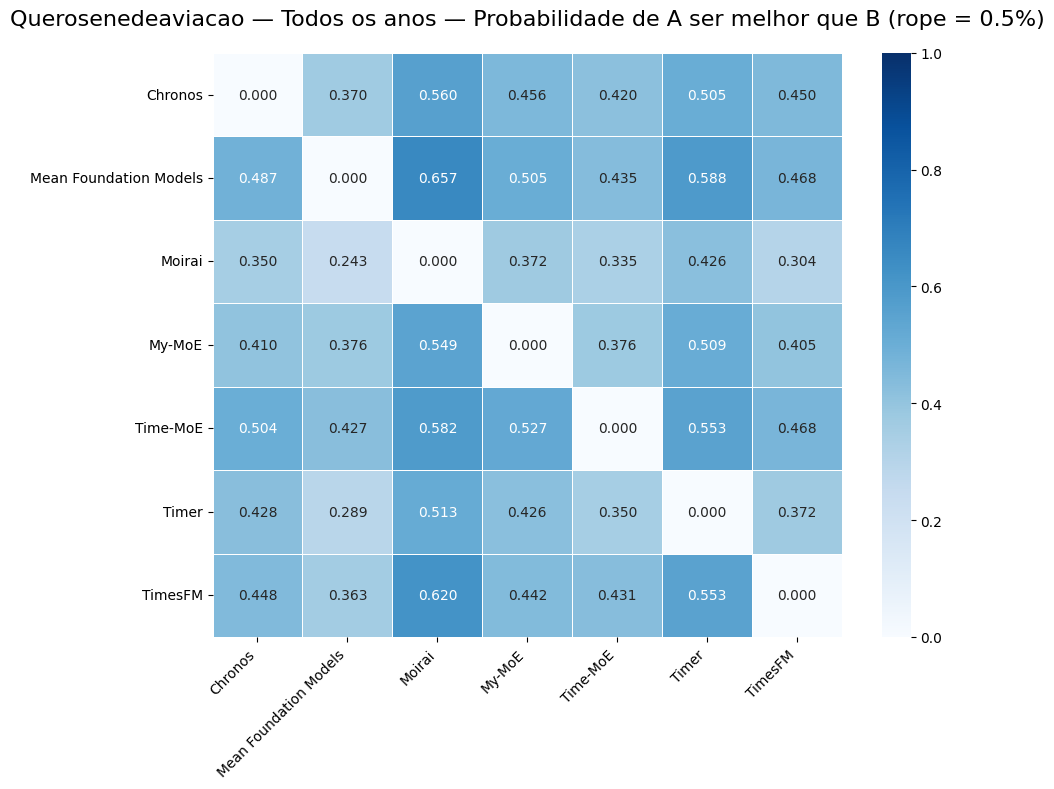

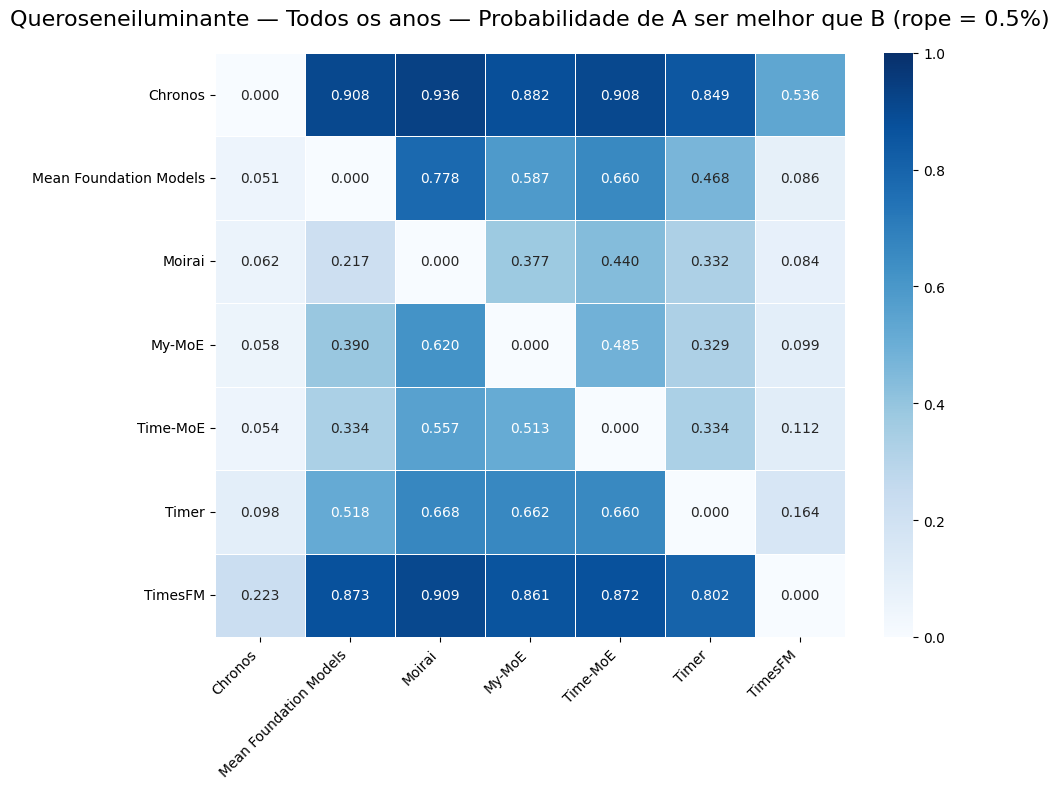

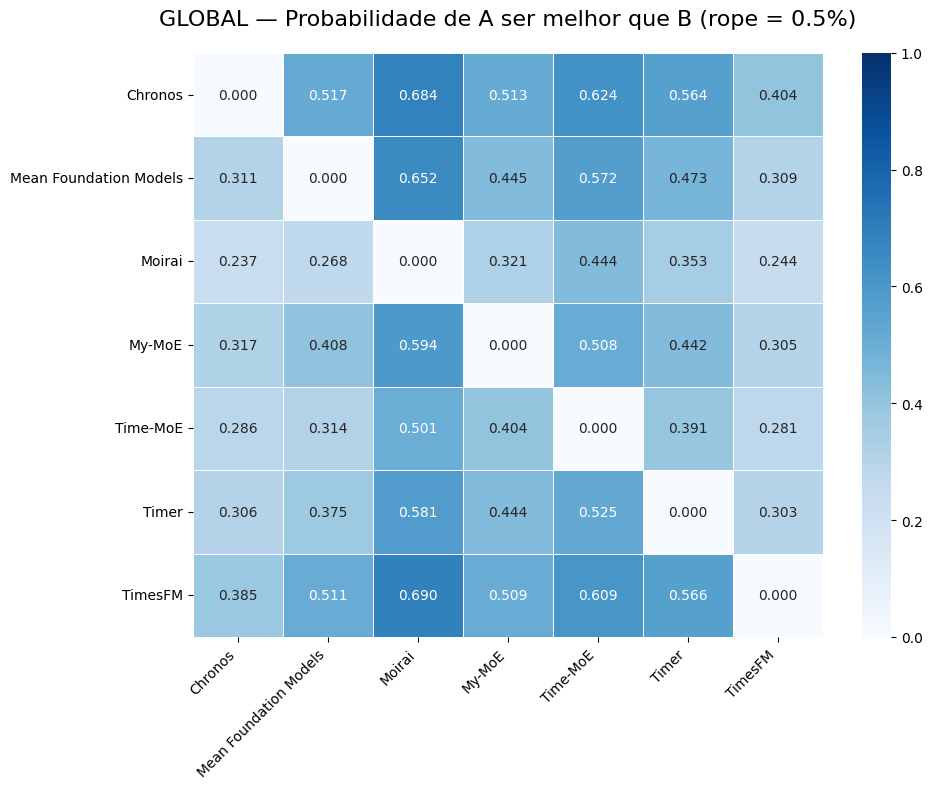

In [3]:
# ================================================
#  IMPORTS
# ================================================
import numpy as np
import pandas as pd
from itertools import combinations
import seaborn as sns
import matplotlib.pyplot as plt


# ================================================
#  1. BAYESIAN SIGNED-RANK TEST
# ================================================
def bayesian_signed_rank(differences, rope=0.5, s=0.5):
    """
    Implementa o Bayesian Signed-Rank Test.
    differences: array das diferenças (B - A) ou (A - B)
    rope: região de equivalência (ex: 0.5 = 0.5% MAPE)
    s: pseudo-contagem do prior Dirichlet (0.5 recomendado)
    """
    diffs = np.array(differences)

    n_left = np.sum(diffs < -rope)         # B melhor
    n_rope = np.sum(np.abs(diffs) <= rope) # equivalentes
    n_right = np.sum(diffs > rope)         # A melhor

    alpha = np.array([n_left + s, n_rope + s, n_right + s])

    # 5000 amostras do posterior Dirichlet
    posterior = np.random.dirichlet(alpha, size=5000)

    theta_left  = posterior[:, 0].mean()
    theta_rope  = posterior[:, 1].mean()
    theta_right = posterior[:, 2].mean()

    return theta_left, theta_rope, theta_right


# ================================================
#  2. GERAR MATRIZ BAYESIANA
# ================================================
def bayesian_matrix(df, rope=0.5, metric="MAPE"):
    modelos = sorted(df["Modelo"].unique())

    mat_better = pd.DataFrame(0.0, index=modelos, columns=modelos)
    mat_rope   = pd.DataFrame(0.0, index=modelos, columns=modelos)

    for A, B in combinations(modelos, 2):
        dfA = df[df["Modelo"] == A][metric].values
        dfB = df[df["Modelo"] == B][metric].values

        if len(dfA) != len(dfB):
            raise ValueError(f"Modelos {A} e {B} têm tamanhos diferentes após filtragem.")

        # menor = melhor (como MAPE), por isso diffs = B - A
        diffs = dfB - dfA

        theta_left, theta_rope, theta_right = bayesian_signed_rank(diffs, rope)

        # chances do modelo A ser melhor (erro menor)
        mat_better.loc[A, B] = theta_right
        mat_better.loc[B, A] = theta_left

        # prob equivalência
        mat_rope.loc[A, B] = theta_rope
        mat_rope.loc[B, A] = theta_rope

    return mat_better, mat_rope


# ================================================
#  3. PLOT ESTILO EXATAMENTE IGUAL AO DA IMAGEM
# ================================================
def plot_bayesian_matrix(matrix, title=""):
    plt.figure(figsize=(10, 8))

    ax = sns.heatmap(
        matrix,
        annot=True,
        fmt=".3f",
        cmap="Blues",
        vmin=0,
        vmax=1,
        linewidths=0.5,
        linecolor='white',
        cbar=True
    )

    ax.set_title(title, fontsize=16, pad=20)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


# ================================================
#  4. EXECUTAR TODAS AS COMBINAÇÕES PEDIDAS
# ================================================
def run_all_bayesian_tests(df_all, rope=0.5, metric="MAPE"):
    resultados = {}

    # A) POR PRODUTO + ANO
    for prod in df_all["Produto"].unique():
        for year in df_all["Year"].unique():
            sub = df_all[(df_all["Produto"] == prod) & (df_all["Year"] == year)]
            if len(sub["Modelo"].unique()) > 1:
                mat_better, mat_rope = bayesian_matrix(sub, rope, metric)
                resultados[(prod, year)] = {
                    "matrix_better": mat_better,
                    "matrix_rope": mat_rope
                }

    # B) POR PRODUTO
    for prod in df_all["Produto"].unique():
        sub = df_all[df_all["Produto"] == prod]
        if len(sub["Modelo"].unique()) > 1:
            mat_better, mat_rope = bayesian_matrix(sub, rope, metric)
            resultados[(prod, "ALL_YEARS")] = {
                "matrix_better": mat_better,
                "matrix_rope": mat_rope
            }

    # C) GLOBAL
    mat_better, mat_rope = bayesian_matrix(df_all, rope, metric)
    resultados["GLOBAL"] = {
        "matrix_better": mat_better,
        "matrix_rope": mat_rope
    }

    return resultados


# =============================================================
#  5. RODAR TUDO E GERAR TODOS OS PLOTS AUTOMATICAMENTE
# =============================================================
# escolha do ROPE (MAPE) — pode ajustar
rope = 0.5   # 0.5% MAPE → sugestão ideal

print("Calculando matrizes bayesianas...")
resultados = run_all_bayesian_tests(df_all, rope=rope, metric="MAPE")

print("Plotando matrizes...\n")

# --- A) PLOTS POR PRODUTO + ANO
for key in resultados:
    if key != "GLOBAL" and key[1] != "ALL_YEARS":
        prod, year = key
        title = f"{prod} — Ano {year} — Probabilidade de A ser melhor que B (rope = {rope}%)"
        plot_bayesian_matrix(resultados[key]["matrix_better"], title)

# --- B) PLOTS POR PRODUTO (TODOS ANOS)
for key in resultados:
    if key != "GLOBAL" and key[1] == "ALL_YEARS":
        prod, _ = key
        title = f"{prod} — Todos os anos — Probabilidade de A ser melhor que B (rope = {rope}%)"
        plot_bayesian_matrix(resultados[key]["matrix_better"], title)

# --- C) PLOT GLOBAL
title = f"GLOBAL — Probabilidade de A ser melhor que B (rope = {rope}%)"
plot_bayesian_matrix(resultados["GLOBAL"]["matrix_better"], title)
